# LSTM Forward Pass — NumPy Implementation
## Every multiplication, addition and activation, shown with numbers

**Course:** Deep Learning for Computer Vision and NLP

**Sentence:** *"Petryk went to school"*

| Parameter | Value |
|-----------|-------|
| Batch size | 1 |
| Sequence length | 4 |
| Vocabulary size | 4 |
| Input size (per token) | 4 (one-hot) |
| **Hidden size** | **3** |
| LSTM layers | 1 |

**What this notebook does.** We push the first **two tokens** ("Petryk", then "went") through an LSTM cell
and show *every single operation* — each matrix–vector product, each bias addition, each activation and each
element-wise product — with:

1. the formula and the **dimensions** of every operand,
2. the arithmetic written out with the **actual numbers**, row by row,
3. a **picture**: heatmaps of matrices and vectors (numbers inside the cells) connected by $\times$, $+$, $\odot$, $=$.

At the end we run the remaining tokens in a compact loop and check that our hand-made LSTM gives exactly
the same numbers as PyTorch's `nn.LSTM`.

**How to read the heatmaps.** Red = positive, blue = negative, white ≈ 0. In each figure all panels share the
same colour scale, so equal colours mean equal values. Row labels `u1, u2, u3` are the three hidden units.

## 1. LSTM Recurrence Equations

The forward pass of a single unidirectional LSTM cell
(from the [PyTorch `nn.LSTM` documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)):

$$i_t = \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) \qquad \text{input gate}$$

$$f_t = \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) \qquad \text{forget gate}$$

$$g_t = \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) \qquad \text{cell candidate}$$

$$o_t = \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) \qquad \text{output gate}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t \qquad \text{new cell state}$$

$$h_t = o_t \odot \tanh(c_t) \qquad \text{new hidden state}$$

Dimensions with `input_size = 4`, `hidden_size = 3`:

| Symbol | Meaning | Shape |
|--------|---------|-------|
| $x_t$ | input at step $t$ (one-hot token) | $4 \times 1$ |
| $h_{t-1},\ c_{t-1}$ | previous hidden / cell state | $3 \times 1$ |
| $W_{i\cdot}$ ($W_{ii}, W_{if}, W_{ig}, W_{io}$) | input → gate weights | $3 \times 4$ |
| $W_{h\cdot}$ ($W_{hi}, W_{hf}, W_{hg}, W_{ho}$) | hidden → gate (recurrent) weights | $3 \times 3$ |
| $b_{i\cdot},\ b_{h\cdot}$ | biases | $3 \times 1$ |
| $i_t, f_t, g_t, o_t, c_t, h_t$ | gates and new states | $3 \times 1$ |

- $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ squashes to $(0, 1)$ — used for the three **gates** (they act like "valves").
- $\tanh(z) = \dfrac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$ squashes to $(-1, 1)$ — used for **content** ($g_t$ and $\tanh(c_t)$).
- $\odot$ is the element-wise (Hadamard) product: $(a \odot b)_k = a_k \cdot b_k$.

Shape check for one gate:
$\underbrace{(3\times4)\cdot(4\times1)}_{3\times1} + \underbrace{3\times1}_{} + \underbrace{(3\times3)\cdot(3\times1)}_{3\times1} + \underbrace{3\times1}_{} = 3\times1$.

**Time indexing used here:** the initial states are $h_0 = c_0 = \mathbf{0}$. Token 1 ("Petryk") is $x_1$ and produces
$h_1, c_1$; token 2 ("went") is $x_2$ and produces $h_2, c_2$, and so on.
(In Python the row index of `X` is `t - 1`.)

## 2. Setup and Parameters

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Math, Markdown

np.set_printoptions(precision=4, suppress=True, linewidth=100)

# --- Parameters ---
batch_size   = 1
seq_len      = 4      # 4 tokens
vocab_size   = 4      # 4 unique words
input_size   = 4      # one-hot dimensionality
hidden_size  = 3      # LSTM hidden/cell size
layers       = 1

print(f"Input per token:          x_t  ∈ R^{input_size}x1")
print(f"Hidden state:             h_t  ∈ R^{hidden_size}x1")
print(f"Cell state:               c_t  ∈ R^{hidden_size}x1")
print(f"W_i* (input weights):     R^{hidden_size}x{input_size}")
print(f"W_h* (recurrent weights): R^{hidden_size}x{hidden_size}")
print(f"b_*  (biases):            R^{hidden_size}x1")

Input per token:          x_t  ∈ R^4x1
Hidden state:             h_t  ∈ R^3x1
Cell state:               c_t  ∈ R^3x1
W_i* (input weights):     R^3x4
W_h* (recurrent weights): R^3x3
b_*  (biases):            R^3x1


### Visualization helpers

The functions below only *display* things — all the actual LSTM math happens in plain NumPy in the cells
that call them (look for `@`, `+`, `*`, `sigmoid`, `tanh`). Each helper:

* prints the **shapes** of the operation,
* prints the **arithmetic** with real numbers (LaTeX),
* draws the **heatmap picture** of the operation.

You can collapse this cell on first reading.

In [73]:
CMAP  = "RdBu_r"
UNITS = [f"u{k + 1}" for k in range(hidden_size)]    # names of the hidden units (rows)
DEC   = 3                                            # decimals shown everywhere


# ----------------------------- LaTeX helpers ---------------------------------
def _n(v):
    """Number for use inside a product/sum: negative numbers get parentheses."""
    s = f"{v:.{DEC}f}"
    return f"({s})" if v < 0 else s

def bmat(M):
    M = np.atleast_2d(M)
    body = r" \\ ".join(" & ".join(f"{v:.{DEC}f}" for v in row) for row in M)
    return r"\begin{bmatrix}" + body + r"\end{bmatrix}"

def bcol(entries):
    return r"\begin{bmatrix}" + r" \\ ".join(entries) + r"\end{bmatrix}"

def dims(A):
    A = np.atleast_2d(A)
    return rf"{A.shape[0]}\times{A.shape[1]}"


# ----------------------------- drawing helpers -------------------------------
def _draw(ax, M, label, vmax, rows=None, cols=None, highlight_col=None, highlight_rows=False):
    M = np.atleast_2d(M)
    ax.imshow(M, cmap=CMAP, vmin=-vmax, vmax=vmax, aspect="equal")
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            v = M[r, c]
            ax.text(c, r, f"{v:.{DEC}f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.6 * vmax else "black")
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels(cols if cols is not None else [""] * M.shape[1], fontsize=8)
    ax.set_yticks(range(M.shape[0]))
    ax.set_yticklabels(rows if rows is not None else [""] * M.shape[0], fontsize=8)
    ax.xaxis.tick_top()
    ax.tick_params(length=0)
    ax.set_xticks(np.arange(-.5, M.shape[1]), minor=True)
    ax.set_yticks(np.arange(-.5, M.shape[0]), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xlabel(label + f"\n({M.shape[0]}×{M.shape[1]})", fontsize=10)
    if highlight_col is not None:
        ax.add_patch(Rectangle((highlight_col - .5, -.5), 1, M.shape[0], fill=False,
                               edgecolor="#2ca02c", linewidth=3.5, zorder=5))
    if highlight_rows is not False:
        ax.add_patch(Rectangle((-.5, highlight_rows - .5), M.shape[1], 1, fill=False,
                               edgecolor="#2ca02c", linewidth=3.5, zorder=5))

def _symbol(ax, s):
    ax.axis("off")
    ax.text(0.5, 0.5, s, ha="center", va="center", fontsize=22, transform=ax.transAxes)

def show_equation(panels, symbols, title=None):
    """panels: list of dicts {M, label, rows, cols, hl, hl_row}; symbols: strings between panels."""
    mats = [np.atleast_2d(p["M"]) for p in panels]
    vmax = max(1e-6, max(np.abs(m).max() for m in mats))
    widths = []
    for k, m in enumerate(mats):
        widths.append(m.shape[1])
        if k < len(symbols):
            widths.append(0.7)
    n_rows = max(m.shape[0] for m in mats)
    fig, axes = plt.subplots(1, len(widths), figsize=(0.95 * sum(widths) + 1.5, 0.8 * n_rows + 1.8),
                             gridspec_kw={"width_ratios": widths})
    axes = np.atleast_1d(axes)
    for k, p in enumerate(panels):
        _draw(axes[2 * k], p["M"], p["label"], vmax, p.get("rows"), p.get("cols"),
              p.get("hl"), p.get("hl_row", False))
        if k < len(symbols):
            _symbol(axes[2 * k + 1], symbols[k])
    if title:
        fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# ----------------------------- operation views -------------------------------
def show_matvec(W, v, out, W_tex, v_tex, out_tex, W_cols, v_rows):
    """out = W @ v, shown as shapes + row-by-row dot products + heatmaps."""
    display(Math(rf"\text{{Shapes: }}\; {W_tex}\,{v_tex}:\quad ({dims(W)})\cdot({dims(v)}) \;\rightarrow\; ({dims(out)})"))
    rows = [" + ".join(rf"{_n(W[r, c])}\cdot{_n(v[c, 0])}" for c in range(W.shape[1]))
            for r in range(W.shape[0])]
    display(Math(rf"{out_tex} = {W_tex}\,{v_tex} = {bmat(W)}{bmat(v)} = {bcol(rows)} = {bmat(out)}"))
    hot = np.flatnonzero(v.ravel())
    hl = int(hot[0]) if (len(hot) == 1 and v.ravel()[hot[0]] == 1.0) else None   # one-hot → highlight column
    show_equation(
        [dict(M=W, label=f"${W_tex}$", rows=UNITS, cols=W_cols, hl=hl),
         dict(M=v, label=f"${v_tex}$", rows=v_rows, hl_row=hl if hl is not None else False),
         dict(M=out, label=f"${out_tex}$", rows=UNITS)],
        ["×", "="])

def show_add(terms, out, out_tex):
    """out = sum of terms; terms = [(vector, tex), ...]."""
    t = " + ".join(tex for _, tex in terms)
    display(Math(rf"\text{{Shapes: }}\; " + " + ".join(f"({dims(v)})" for v, _ in terms)
                 + rf" \;\rightarrow\; ({dims(out)})"))
    rows = [" + ".join(_n(v[r, 0]) for v, _ in terms) for r in range(out.shape[0])]
    lhs = out_tex if out_tex == t else f"{out_tex} = {t}"
    display(Math(rf"{lhs} = " + " + ".join(bmat(v) for v, _ in terms)
                 + rf" = {bcol(rows)} = {bmat(out)}"))
    show_equation([dict(M=v, label=f"${tex}$", rows=UNITS) for v, tex in terms]
                  + [dict(M=out, label=f"${out_tex}$", rows=UNITS)],
                  ["+"] * (len(terms) - 1) + ["="])

def show_hadamard(a, b, out, a_tex, b_tex, out_tex):
    """out = a ⊙ b (element-wise product)."""
    display(Math(rf"\text{{Shapes: }}\; ({dims(a)}) \odot ({dims(b)}) \;\rightarrow\; ({dims(out)})"))
    rows = [rf"{_n(a[r, 0])}\cdot{_n(b[r, 0])}" for r in range(out.shape[0])]
    display(Math(rf"{out_tex} = {a_tex} \odot {b_tex} = {bmat(a)} \odot {bmat(b)} = {bcol(rows)} = {bmat(out)}"))
    show_equation([dict(M=a, label=f"${a_tex}$", rows=UNITS),
                   dict(M=b, label=f"${b_tex}$", rows=UNITS),
                   dict(M=out, label=f"${out_tex}$", rows=UNITS)],
                  ["⊙", "="])

def show_activation(z, a, kind, z_tex, a_tex):
    """a = sigmoid(z) or tanh(z): element-wise formula with numbers + curve with the points marked."""
    zr = z.ravel()
    if kind == "sigmoid":
        fn, name, plain = sigmoid, r"\sigma", "σ"
        step1 = [rf"\dfrac{{1}}{{1 + e^{{-{_n(v)}}}}}" for v in zr]
        step2 = [rf"\dfrac{{1}}{{1 + {np.exp(-v):.{DEC}f}}}" for v in zr]
    else:
        fn, name, plain = tanh, r"\tanh", "tanh"
        step1 = [rf"\dfrac{{e^{{{_n(v)}}} - e^{{-{_n(v)}}}}}{{e^{{{_n(v)}}} + e^{{-{_n(v)}}}}}" for v in zr]
        step2 = [rf"\dfrac{{{np.exp(v):.{DEC}f} - {np.exp(-v):.{DEC}f}}}{{{np.exp(v):.{DEC}f} + {np.exp(-v):.{DEC}f}}}" for v in zr]
    display(Math(rf"\text{{Shapes: }}\; {name}({dims(z)}) \;\rightarrow\; ({dims(a)}) \quad \text{{(applied to each element separately)}}"))
    display(Math(rf"{a_tex} = {name}({z_tex}) = {name}{bmat(z)} = {bcol(step1)} = {bcol(step2)} = {bmat(a)}"))

    vmax = max(1e-6, np.abs(z).max(), np.abs(a).max())
    fig, axes = plt.subplots(1, 5, figsize=(10.5, 3.4), gridspec_kw={"width_ratios": [1, 0.6, 4, 0.6, 1]})
    _draw(axes[0], z, f"${z_tex}$", vmax, rows=UNITS)
    _symbol(axes[1], "→")
    _draw(axes[4], a, f"${a_tex}$", vmax, rows=UNITS)
    _symbol(axes[3], "→")
    ax = axes[2]
    lim = max(4.0, np.abs(zr).max() + 0.5)
    zz = np.linspace(-lim, lim, 400)
    ax.plot(zz, fn(zz), color="gray", lw=2)
    ax.axhline(0, color="lightgray", lw=0.8); ax.axvline(0, color="lightgray", lw=0.8)
    colors = plt.cm.tab10(range(len(zr)))
    for k, (zv, av) in enumerate(zip(zr, a.ravel())):
        ax.plot([zv, zv], [0, av], ls=":", color=colors[k])
        ax.scatter([zv], [av], color=colors[k], s=60, zorder=5,
                   label=f"{UNITS[k]}: {plain}({zv:.3f}) = {av:.3f}")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_title(f"${name}(z)$ applied element-wise", fontsize=10)
    ax.set_xlabel("z"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def show_states(panels, title):
    """Side-by-side heatmaps of several vectors (no operator symbols)."""
    show_equation(panels, [""] * (len(panels) - 1), title)

## 3. Input Data — One-hot Encoding

Vocabulary: `Petryk=0, went=1, to=2, school=3`

Each token becomes a one-hot vector $x_t \in \mathbb{R}^{4 \times 1}$: a single 1 at the token's index, zeros elsewhere.
Stacking the 4 tokens gives $X \in \mathbb{R}^{4 \times 4}$ (sequence_len × input_size; batch = 1 omitted).

X =
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


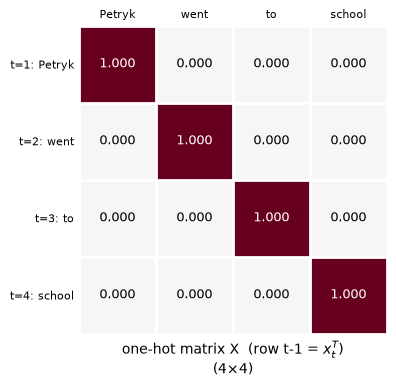

In [74]:
tokens = ["Petryk", "went", "to", "school"]
vocab  = {t: i for i, t in enumerate(tokens)}

# One-hot encode: shape (seq_len, input_size) = (4, 4)
X = np.zeros((seq_len, input_size), dtype=np.float64)
for t_idx, tok in enumerate(tokens):
    X[t_idx, vocab[tok]] = 1.0

print("X =\n", X)

fig, ax = plt.subplots(figsize=(4.5, 4))
_draw(ax, X, "one-hot matrix X  (row t-1 = $x_t^T$)", 1.0,
      rows=[f"t={k + 1}: {tok}" for k, tok in enumerate(tokens)], cols=tokens)
plt.show()

## 4. Weight Initialization

We create **8 weight matrices** and **8 bias vectors** (4 gates × {input weight, recurrent weight, 2 biases}):

| Gate | Input weight $W_{i\cdot}$ | Recurrent weight $W_{h\cdot}$ | Biases |
|------|---------------------------|-------------------------------|--------|
| Input ($i$) | $W_{ii} \in \mathbb{R}^{3\times4}$ | $W_{hi} \in \mathbb{R}^{3\times3}$ | $b_{ii},\; b_{hi} \in \mathbb{R}^{3\times1}$ |
| Forget ($f$) | $W_{if} \in \mathbb{R}^{3\times4}$ | $W_{hf} \in \mathbb{R}^{3\times3}$ | $b_{if},\; b_{hf} \in \mathbb{R}^{3\times1}$ |
| Cell ($g$) | $W_{ig} \in \mathbb{R}^{3\times4}$ | $W_{hg} \in \mathbb{R}^{3\times3}$ | $b_{ig},\; b_{hg} \in \mathbb{R}^{3\times1}$ |
| Output ($o$) | $W_{io} \in \mathbb{R}^{3\times4}$ | $W_{ho} \in \mathbb{R}^{3\times3}$ | $b_{io},\; b_{ho} \in \mathbb{R}^{3\times1}$ |

Total: $4 \cdot (3\cdot4 + 3\cdot3 + 3 + 3) = 4 \cdot 27 = 108$ parameters.

We store biases as **column vectors** ($3\times1$) so that every addition below is a clean
"column + column". (PyTorch stores them as 1-D tensors of length 3 — same numbers.)

In [75]:
rng = np.random.default_rng(seed=42)

# Input-to-gate weights: each ∈ R^{3 x 4}
W_ii = rng.standard_normal((hidden_size, input_size))   # input gate
W_if = rng.standard_normal((hidden_size, input_size))   # forget gate
W_ig = rng.standard_normal((hidden_size, input_size))   # cell candidate
W_io = rng.standard_normal((hidden_size, input_size))   # output gate

# Recurrent (hidden-to-gate) weights: each ∈ R^{3 x 3}
W_hi = rng.standard_normal((hidden_size, hidden_size))
W_hf = rng.standard_normal((hidden_size, hidden_size))
W_hg = rng.standard_normal((hidden_size, hidden_size))
W_ho = rng.standard_normal((hidden_size, hidden_size))

# Biases: each ∈ R^{3 x 1} (column vectors)
b_ii = rng.standard_normal((hidden_size, 1))
b_hi = rng.standard_normal((hidden_size, 1))
b_if = rng.standard_normal((hidden_size, 1))
b_hf = rng.standard_normal((hidden_size, 1))
b_ig = rng.standard_normal((hidden_size, 1))
b_hg = rng.standard_normal((hidden_size, 1))
b_io = rng.standard_normal((hidden_size, 1))
b_ho = rng.standard_normal((hidden_size, 1))

print("Weights initialized (seed=42)")
for name in ["W_ii", "W_if", "W_ig", "W_io", "W_hi", "W_hf", "W_hg", "W_ho",
             "b_ii", "b_hi", "b_if", "b_hf", "b_ig", "b_hg", "b_io", "b_ho"]:
    print(f"  {name}: shape {globals()[name].shape}")

Weights initialized (seed=42)
  W_ii: shape (3, 4)
  W_if: shape (3, 4)
  W_ig: shape (3, 4)
  W_io: shape (3, 4)
  W_hi: shape (3, 3)
  W_hf: shape (3, 3)
  W_hg: shape (3, 3)
  W_ho: shape (3, 3)
  b_ii: shape (3, 1)
  b_hi: shape (3, 1)
  b_if: shape (3, 1)
  b_hf: shape (3, 1)
  b_ig: shape (3, 1)
  b_hg: shape (3, 1)
  b_io: shape (3, 1)
  b_ho: shape (3, 1)


### All parameters at a glance

One row per gate. Columns: input weights $W_{i\cdot}$ (columns = which token), recurrent weights $W_{h\cdot}$
(columns = which unit of $h_{t-1}$), and the two biases. All panels share one colour scale.

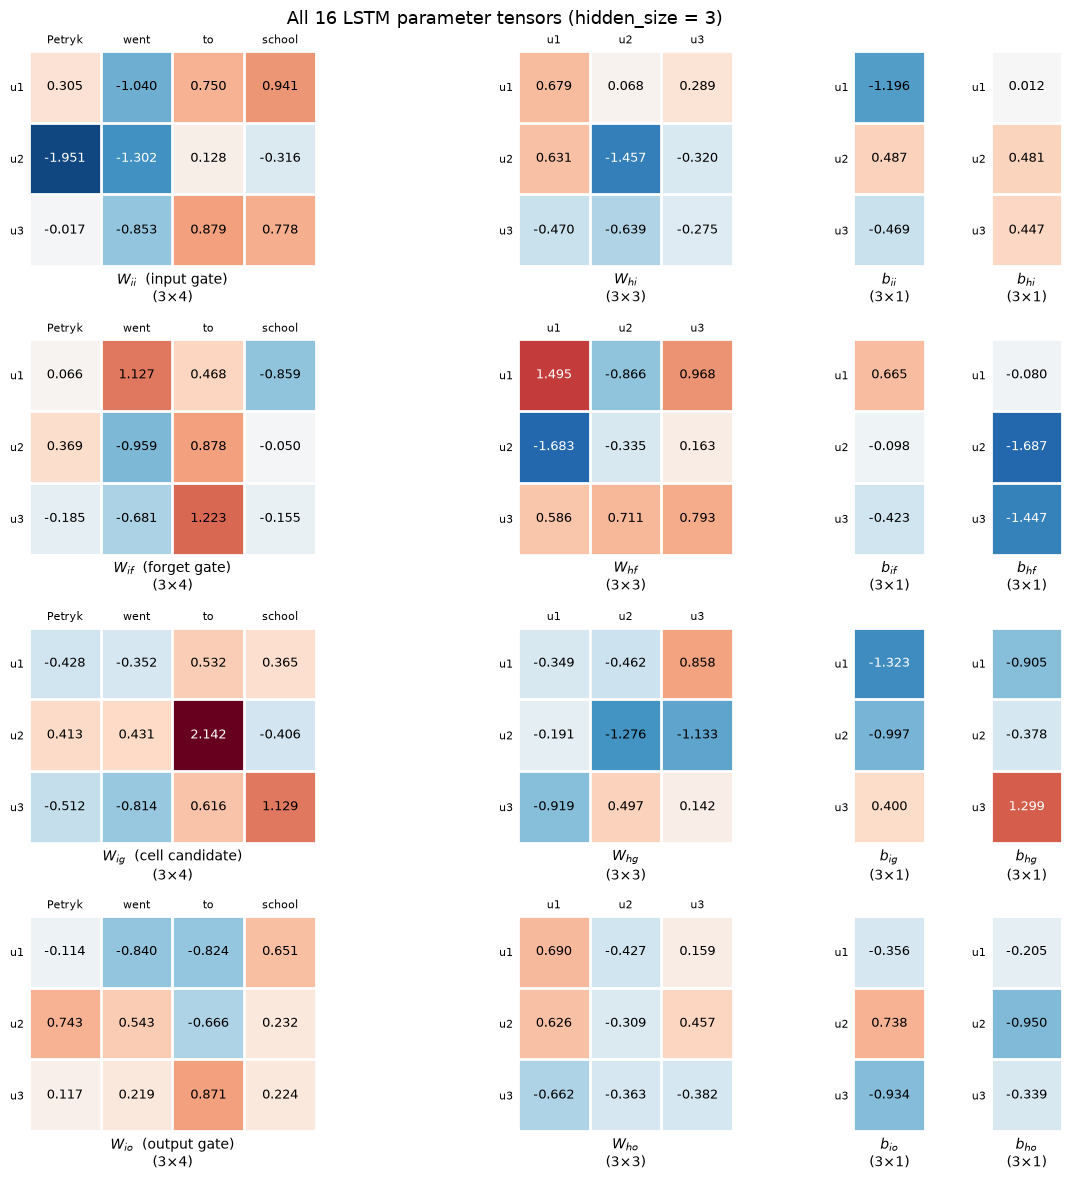

In [76]:
gate_params = [("i", "input gate"), ("f", "forget gate"), ("g", "cell candidate"), ("o", "output gate")]
vmax_all = max(np.abs(globals()[f"{p}{g}"]).max()
               for g, _ in gate_params for p in ["W_i", "W_h", "b_i", "b_h"])

fig, axes = plt.subplots(4, 4, figsize=(12, 12), gridspec_kw={"width_ratios": [4, 3, 1, 1]})
for r, (g, gname) in enumerate(gate_params):
    _draw(axes[r, 0], globals()[f"W_i{g}"], f"$W_{{i{g}}}$  ({gname})", vmax_all, rows=UNITS, cols=tokens)
    _draw(axes[r, 1], globals()[f"W_h{g}"], f"$W_{{h{g}}}$", vmax_all, rows=UNITS, cols=UNITS)
    _draw(axes[r, 2], globals()[f"b_i{g}"], f"$b_{{i{g}}}$", vmax_all, rows=UNITS)
    _draw(axes[r, 3], globals()[f"b_h{g}"], f"$b_{{h{g}}}$", vmax_all, rows=UNITS)
fig.suptitle("All 16 LSTM parameter tensors (hidden_size = 3)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Activation Functions

$$\sigma(z) = \frac{1}{1+e^{-z}} \in (0,1) \qquad\qquad \tanh(z) = \frac{e^{z}-e^{-z}}{e^{z}+e^{-z}} \in (-1,1)$$

Both are applied **element-wise**: a $3\times1$ vector goes in, a $3\times1$ vector comes out.

sigmoid([-2, 0, 2]) = [0.1192 0.5    0.8808]
tanh([-2, 0, 2])    = [-0.964  0.     0.964]


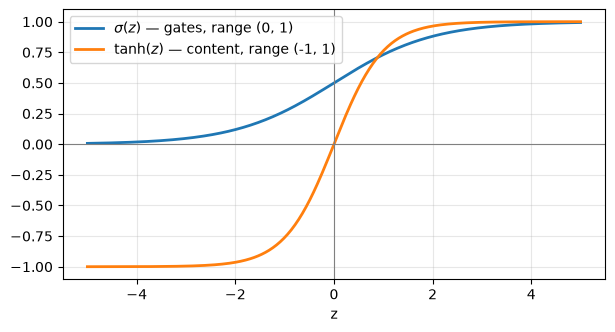

In [77]:
def sigmoid(z):
    """σ(z) = 1 / (1 + exp(-z))"""
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    """tanh(z) = (exp(z) - exp(-z)) / (exp(z) + exp(-z))"""
    return np.tanh(z)

print("sigmoid([-2, 0, 2]) =", sigmoid(np.array([-2., 0., 2.])))
print("tanh([-2, 0, 2])    =", tanh(np.array([-2., 0., 2.])))

zz = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(zz, sigmoid(zz), lw=2, label=r"$\sigma(z)$ — gates, range (0, 1)")
ax.plot(zz, tanh(zz), lw=2, label=r"$\tanh(z)$ — content, range (-1, 1)")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.grid(alpha=0.3); ax.legend(); ax.set_xlabel("z")
plt.show()

---

## 6. Pass 1 — token $x_1$ = "Petryk"

**Inputs of this step**

| Quantity | Where it comes from | Shape |
|----------|--------------------|-------|
| $x_1$ | one-hot vector of "Petryk" (row 0 of `X`) | $4\times1$ |
| $h_0$ | initial hidden state, all zeros | $3\times1$ |
| $c_0$ | initial cell state, all zeros | $3\times1$ |

**Outputs:** $h_1$, $c_1$ (both $3\times1$).

Plan: compute the four gates $i_1, f_1, g_1, o_1$ (each in 6 small steps: matrix·vector, + bias,
matrix·vector, + bias, sum, activation), then the cell state $c_1$ and the hidden state $h_1$.

x1 shape: (4, 1)  h0 shape: (3, 1)  c0 shape: (3, 1)


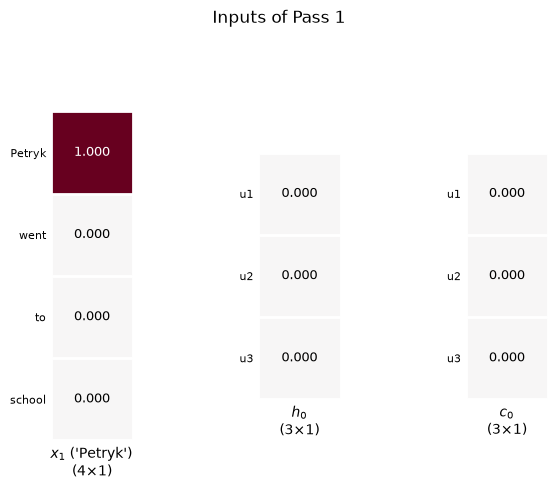

In [78]:
x1 = X[0].reshape(-1, 1)                             # x_1 ∈ R^{4x1}: one-hot for "Petryk"
h0 = np.zeros((hidden_size, 1), dtype=np.float64)    # h_0 ∈ R^{3x1}: initial hidden state
c0 = np.zeros((hidden_size, 1), dtype=np.float64)    # c_0 ∈ R^{3x1}: initial cell state

print("x1 shape:", x1.shape, " h0 shape:", h0.shape, " c0 shape:", c0.shape)
show_states([dict(M=x1, label="$x_1$ ('Petryk')", rows=tokens),
             dict(M=h0, label="$h_0$", rows=UNITS),
             dict(M=c0, label="$c_0$", rows=UNITS)], "Inputs of Pass 1")

### 6.1 — Input gate $i_1$

$$i_1 = \sigma\big(\underbrace{W_{ii}\,x_1}_{\text{step a}} \underbrace{+\, b_{ii}}_{\text{step b}}
\;+\; \underbrace{W_{hi}\,h_0}_{\text{step c}} \underbrace{+\, b_{hi}}_{\text{step d}}\big)$$

The Input gate decides **how much of the new candidate** $g_t$ is written into the cell state. Values near 1 = "write", near 0 = "ignore".

**Step a — input projection** $\;W_{ii}\,x_1$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{ii}$ is dotted with $x_1$ (4 products, then summed).
Because $x_1$ is **one-hot** with the 1 at position 0 ("Petryk"), every product is zero except one:
the result is simply **column 0 of $W_{ii}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

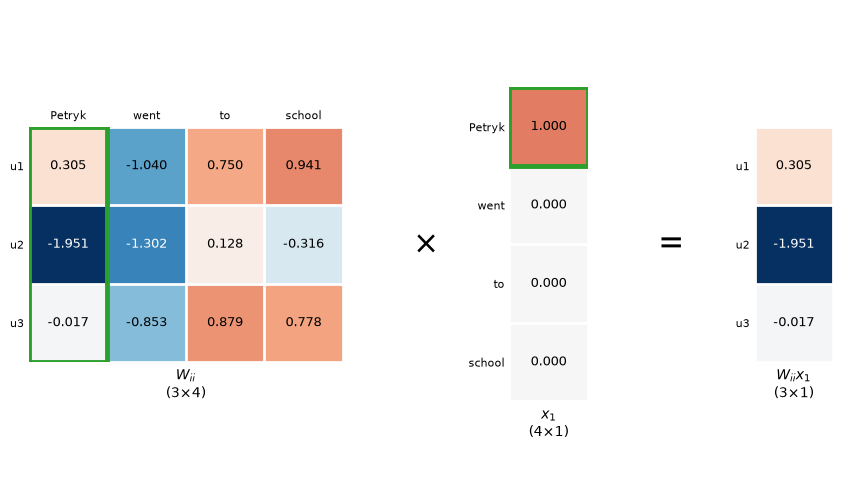

In [79]:
W_ii_x1 = W_ii @ x1          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_ii, x1, W_ii_x1, r"W_{ii}", r"x_1", r"W_{ii}x_1", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{ii}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

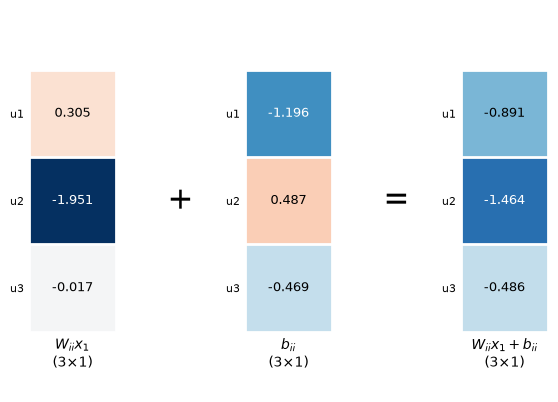

In [80]:
W_ii_x1_b = W_ii_x1 + b_ii       # (3x1) + (3x1) -> (3x1)
show_add([(W_ii_x1, r"W_{ii}x_1"), (b_ii, r"b_{ii}")], W_ii_x1_b, r"W_{ii}x_1 + b_{ii}")

**Step c — recurrent projection** $\;W_{hi}\,h_0$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hi}$ is dotted with the previous hidden state $h_0$ (3 products, then summed).
Here $h_0 = \mathbf{0}$, so **every product is zero** and the result is the zero vector — at the very first step the recurrent weights have nothing to work with. (Compare with the same step in Pass 2!)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

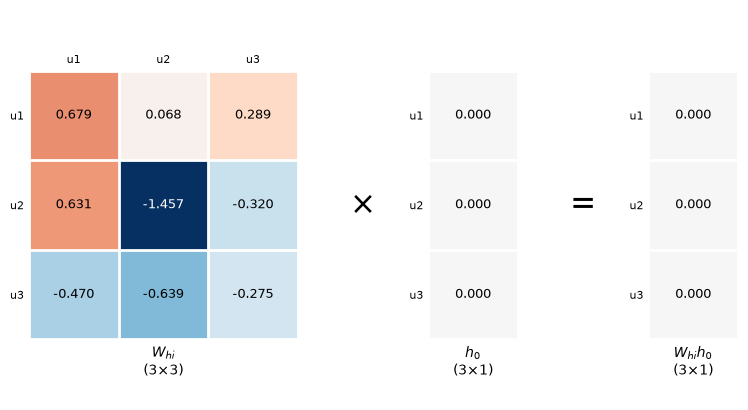

In [81]:
W_hi_h0 = W_hi @ h0          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hi, h0, W_hi_h0, r"W_{hi}", r"h_0", r"W_{hi}h_0", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hi}$: $\;(3\times1) + (3\times1) = (3\times1)$
(Since $W_{h\cdot}h_0 = \mathbf{0}$, the result is just the bias itself.)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

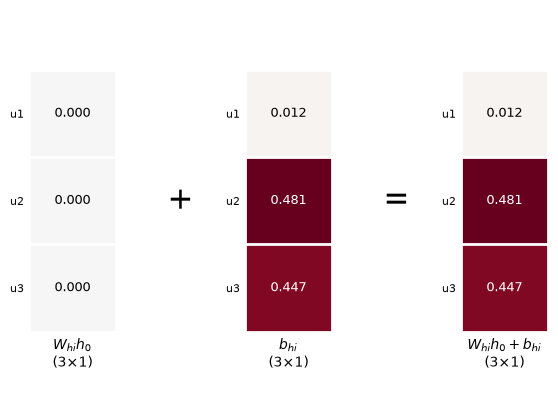

In [82]:
W_hi_h0_b = W_hi_h0 + b_hi       # (3x1) + (3x1) -> (3x1)
show_add([(W_hi_h0, r"W_{hi}h_0"), (b_hi, r"b_{hi}")], W_hi_h0_b, r"W_{hi}h_0 + b_{hi}")

**Step e — total pre-activation** $\;z^{(i)}_1 = (W_{ii}x_1 + b_{ii}) + (W_{hi}h_0 + b_{hi})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(i)}_1$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

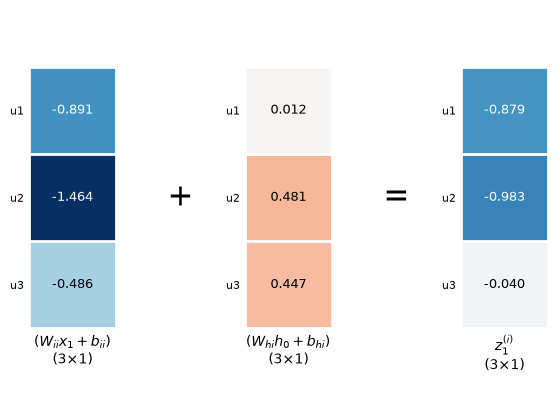

In [83]:
z_i1 = W_ii_x1_b + W_hi_h0_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_ii_x1_b, r"(W_{ii}x_1 + b_{ii})"), (W_hi_h0_b, r"(W_{hi}h_0 + b_{hi})")], z_i1, r"z^{(i)}_1")

**Step f — activation** $\;i_1 = \sigma(z^{(i)}_1)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

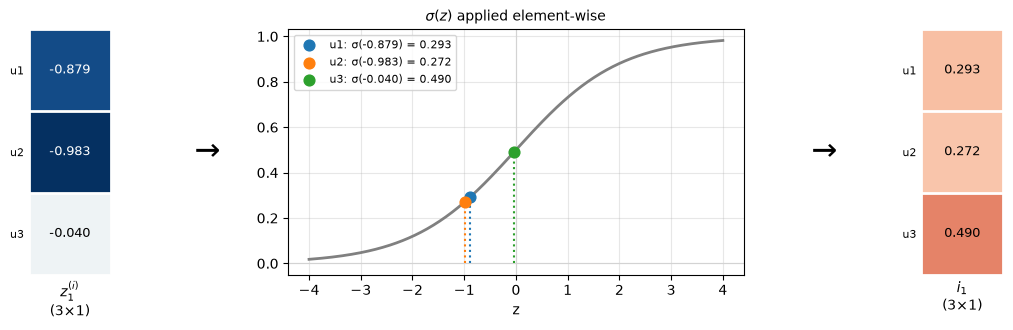

In [84]:
i1 = sigmoid(z_i1)          # element-wise -> (3x1)
show_activation(z_i1, i1, "sigmoid", r"z^{(i)}_1", r"i_1")

### 6.2 — Forget gate $f_1$

$$f_1 = \sigma\big(\underbrace{W_{if}\,x_1}_{\text{step a}} \underbrace{+\, b_{if}}_{\text{step b}}
\;+\; \underbrace{W_{hf}\,h_0}_{\text{step c}} \underbrace{+\, b_{hf}}_{\text{step d}}\big)$$

The Forget gate decides **how much of the old cell state** $c_{t-1}$ is kept. Values near 1 = "remember", near 0 = "forget".

**Step a — input projection** $\;W_{if}\,x_1$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{if}$ is dotted with $x_1$ (4 products, then summed).
Because $x_1$ is **one-hot** with the 1 at position 0 ("Petryk"), every product is zero except one:
the result is simply **column 0 of $W_{if}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

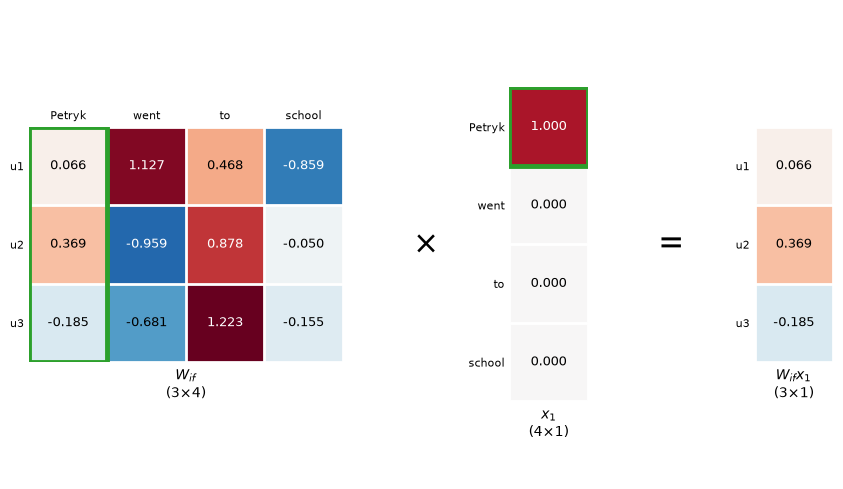

In [85]:
W_if_x1 = W_if @ x1          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_if, x1, W_if_x1, r"W_{if}", r"x_1", r"W_{if}x_1", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{if}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

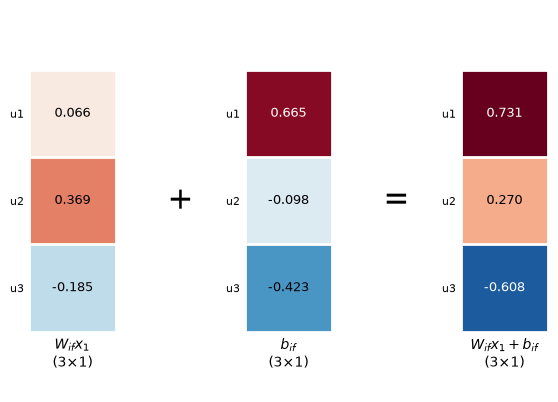

In [86]:
W_if_x1_b = W_if_x1 + b_if       # (3x1) + (3x1) -> (3x1)
show_add([(W_if_x1, r"W_{if}x_1"), (b_if, r"b_{if}")], W_if_x1_b, r"W_{if}x_1 + b_{if}")

**Step c — recurrent projection** $\;W_{hf}\,h_0$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hf}$ is dotted with the previous hidden state $h_0$ (3 products, then summed).
Here $h_0 = \mathbf{0}$, so **every product is zero** and the result is the zero vector — at the very first step the recurrent weights have nothing to work with. (Compare with the same step in Pass 2!)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

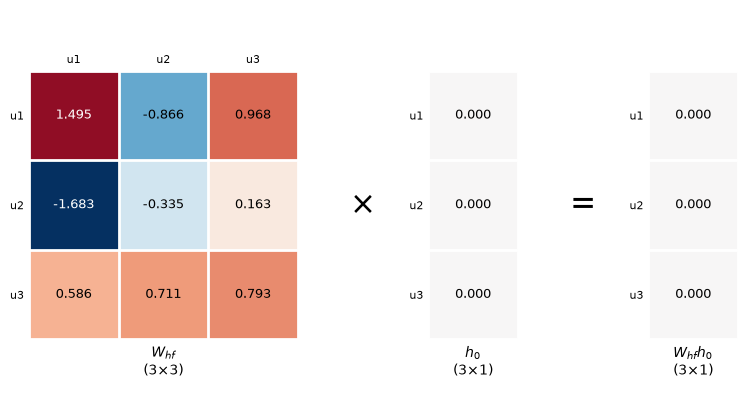

In [87]:
W_hf_h0 = W_hf @ h0          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hf, h0, W_hf_h0, r"W_{hf}", r"h_0", r"W_{hf}h_0", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hf}$: $\;(3\times1) + (3\times1) = (3\times1)$
(Since $W_{h\cdot}h_0 = \mathbf{0}$, the result is just the bias itself.)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

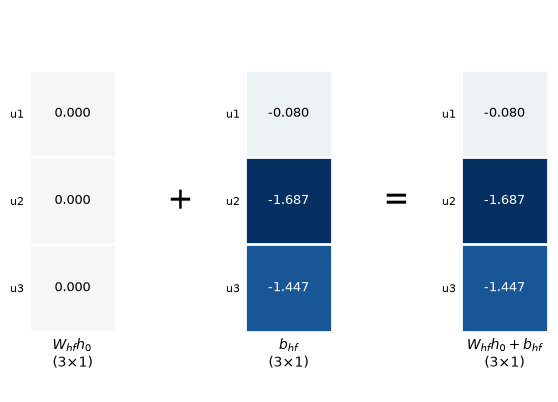

In [88]:
W_hf_h0_b = W_hf_h0 + b_hf       # (3x1) + (3x1) -> (3x1)
show_add([(W_hf_h0, r"W_{hf}h_0"), (b_hf, r"b_{hf}")], W_hf_h0_b, r"W_{hf}h_0 + b_{hf}")

**Step e — total pre-activation** $\;z^{(f)}_1 = (W_{if}x_1 + b_{if}) + (W_{hf}h_0 + b_{hf})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(f)}_1$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

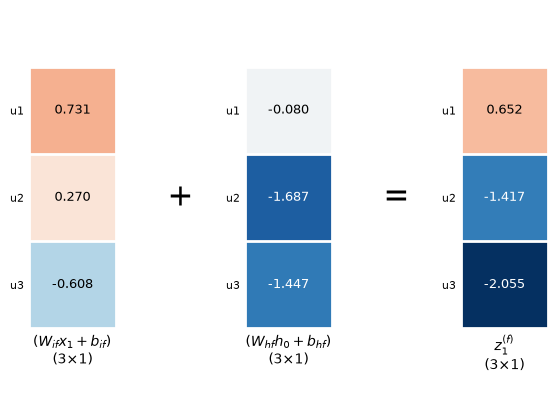

In [89]:
z_f1 = W_if_x1_b + W_hf_h0_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_if_x1_b, r"(W_{if}x_1 + b_{if})"), (W_hf_h0_b, r"(W_{hf}h_0 + b_{hf})")], z_f1, r"z^{(f)}_1")

**Step f — activation** $\;f_1 = \sigma(z^{(f)}_1)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

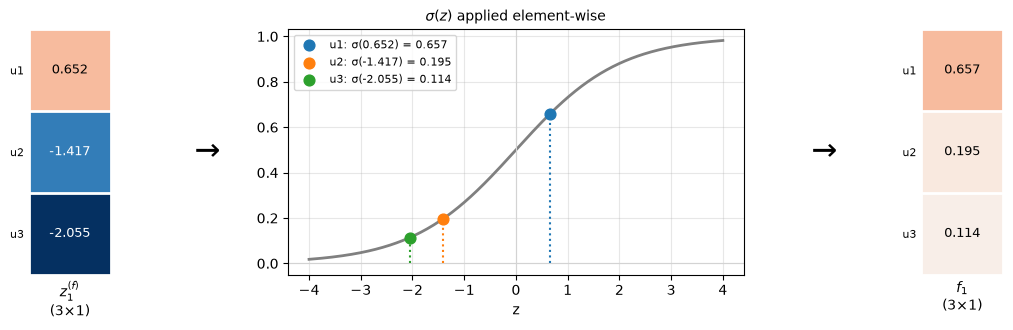

In [90]:
f1 = sigmoid(z_f1)          # element-wise -> (3x1)
show_activation(z_f1, f1, "sigmoid", r"z^{(f)}_1", r"f_1")

### 6.3 — Cell candidate $g_1$

$$g_1 = \tanh\big(\underbrace{W_{ig}\,x_1}_{\text{step a}} \underbrace{+\, b_{ig}}_{\text{step b}}
\;+\; \underbrace{W_{hg}\,h_0}_{\text{step c}} \underbrace{+\, b_{hg}}_{\text{step d}}\big)$$

The Cell candidate proposes **new content** for the cell state, in the range $(-1, 1)$. It is not a gate — it is the information itself, hence $\tanh$ instead of $\sigma$.

**Step a — input projection** $\;W_{ig}\,x_1$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{ig}$ is dotted with $x_1$ (4 products, then summed).
Because $x_1$ is **one-hot** with the 1 at position 0 ("Petryk"), every product is zero except one:
the result is simply **column 0 of $W_{ig}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

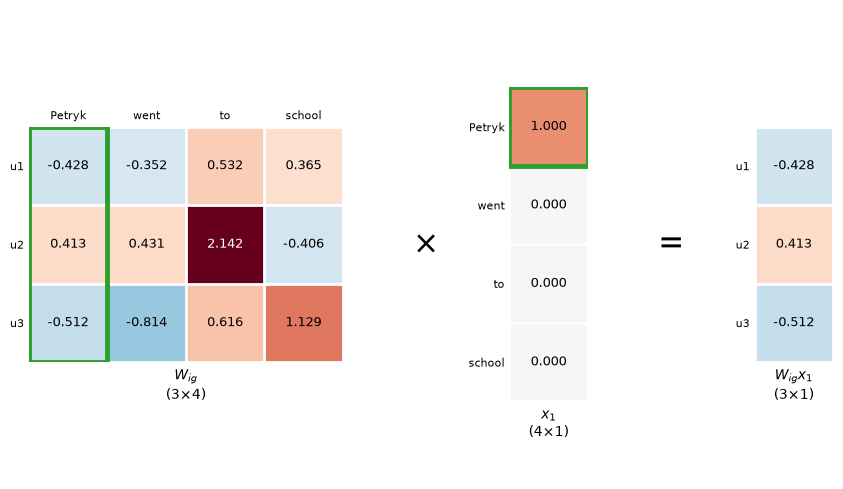

In [91]:
W_ig_x1 = W_ig @ x1          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_ig, x1, W_ig_x1, r"W_{ig}", r"x_1", r"W_{ig}x_1", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{ig}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

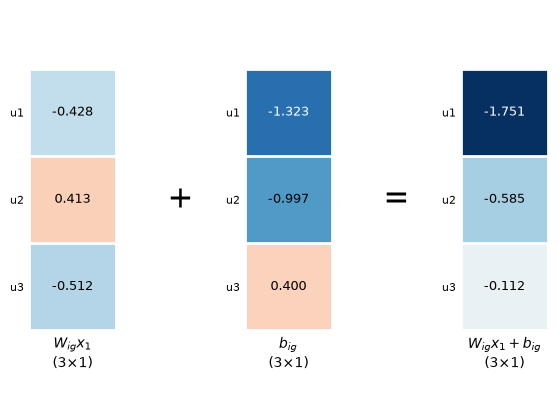

In [92]:
W_ig_x1_b = W_ig_x1 + b_ig       # (3x1) + (3x1) -> (3x1)
show_add([(W_ig_x1, r"W_{ig}x_1"), (b_ig, r"b_{ig}")], W_ig_x1_b, r"W_{ig}x_1 + b_{ig}")

**Step c — recurrent projection** $\;W_{hg}\,h_0$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hg}$ is dotted with the previous hidden state $h_0$ (3 products, then summed).
Here $h_0 = \mathbf{0}$, so **every product is zero** and the result is the zero vector — at the very first step the recurrent weights have nothing to work with. (Compare with the same step in Pass 2!)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

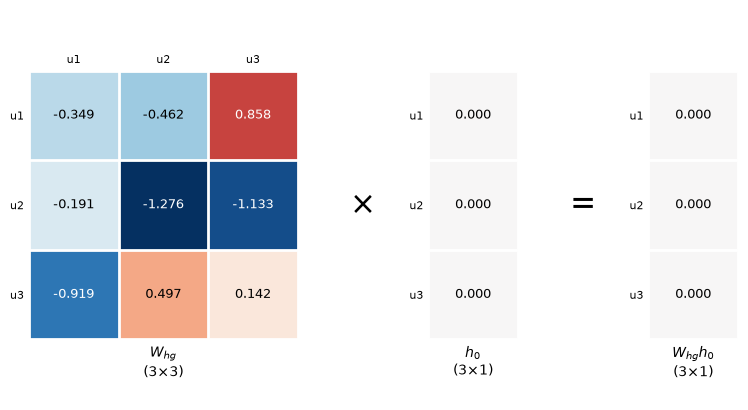

In [93]:
W_hg_h0 = W_hg @ h0          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hg, h0, W_hg_h0, r"W_{hg}", r"h_0", r"W_{hg}h_0", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hg}$: $\;(3\times1) + (3\times1) = (3\times1)$
(Since $W_{h\cdot}h_0 = \mathbf{0}$, the result is just the bias itself.)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

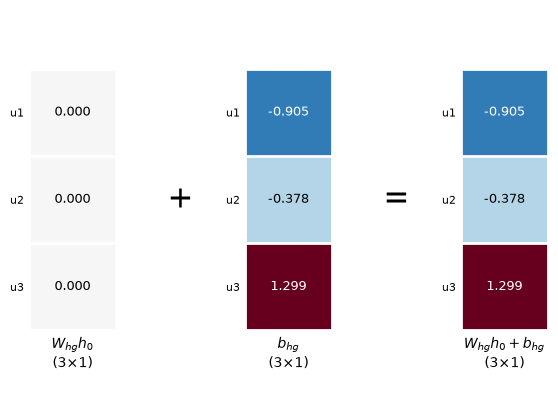

In [94]:
W_hg_h0_b = W_hg_h0 + b_hg       # (3x1) + (3x1) -> (3x1)
show_add([(W_hg_h0, r"W_{hg}h_0"), (b_hg, r"b_{hg}")], W_hg_h0_b, r"W_{hg}h_0 + b_{hg}")

**Step e — total pre-activation** $\;z^{(g)}_1 = (W_{ig}x_1 + b_{ig}) + (W_{hg}h_0 + b_{hg})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(g)}_1$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

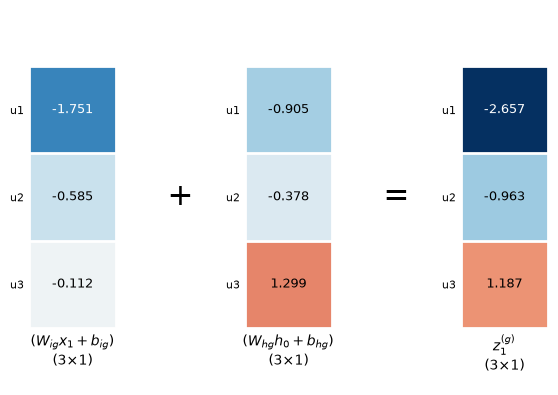

In [95]:
z_g1 = W_ig_x1_b + W_hg_h0_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_ig_x1_b, r"(W_{ig}x_1 + b_{ig})"), (W_hg_h0_b, r"(W_{hg}h_0 + b_{hg})")], z_g1, r"z^{(g)}_1")

**Step f — activation** $\;g_1 = \tanh(z^{(g)}_1)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\tanh$ maps every entry into $(-1, 1)$, so the candidate can push the cell state **up or down**. $\tanh(0) = 0$.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

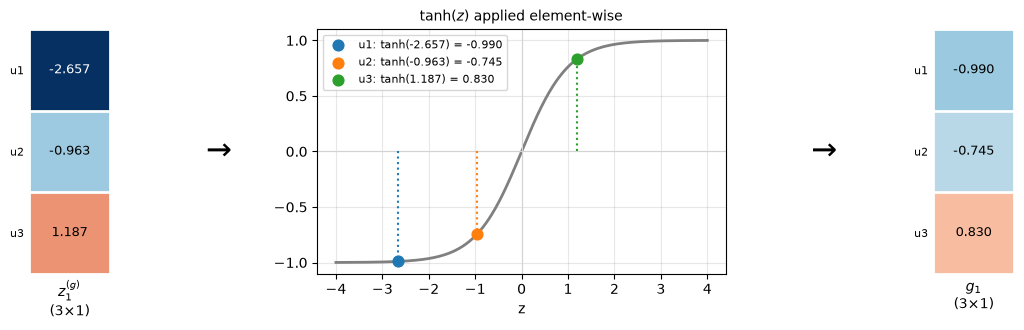

In [96]:
g1 = tanh(z_g1)          # element-wise -> (3x1)
show_activation(z_g1, g1, "tanh", r"z^{(g)}_1", r"g_1")

### 6.4 — Output gate $o_1$

$$o_1 = \sigma\big(\underbrace{W_{io}\,x_1}_{\text{step a}} \underbrace{+\, b_{io}}_{\text{step b}}
\;+\; \underbrace{W_{ho}\,h_0}_{\text{step c}} \underbrace{+\, b_{ho}}_{\text{step d}}\big)$$

The Output gate decides **how much of the (squashed) cell state** $\tanh(c_t)$ is exposed as the hidden state $h_t$.

**Step a — input projection** $\;W_{io}\,x_1$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{io}$ is dotted with $x_1$ (4 products, then summed).
Because $x_1$ is **one-hot** with the 1 at position 0 ("Petryk"), every product is zero except one:
the result is simply **column 0 of $W_{io}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

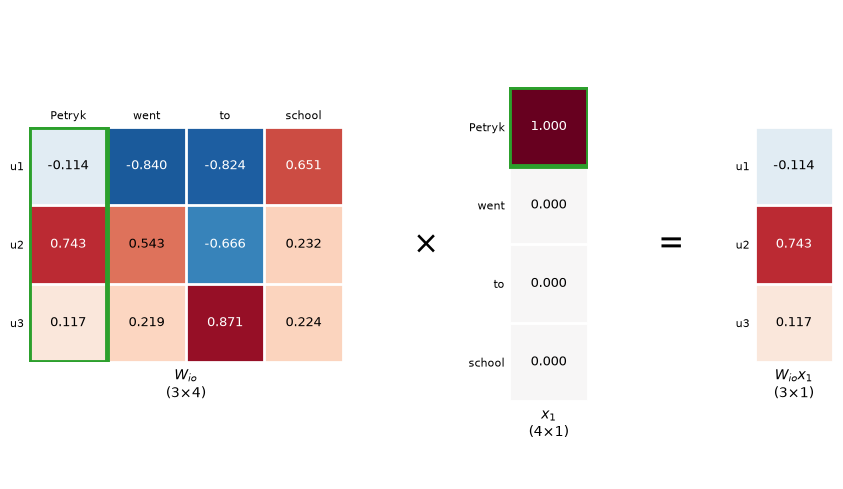

In [97]:
W_io_x1 = W_io @ x1          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_io, x1, W_io_x1, r"W_{io}", r"x_1", r"W_{io}x_1", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{io}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

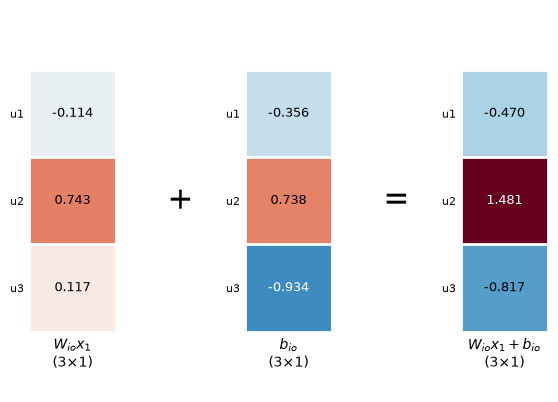

In [98]:
W_io_x1_b = W_io_x1 + b_io       # (3x1) + (3x1) -> (3x1)
show_add([(W_io_x1, r"W_{io}x_1"), (b_io, r"b_{io}")], W_io_x1_b, r"W_{io}x_1 + b_{io}")

**Step c — recurrent projection** $\;W_{ho}\,h_0$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{ho}$ is dotted with the previous hidden state $h_0$ (3 products, then summed).
Here $h_0 = \mathbf{0}$, so **every product is zero** and the result is the zero vector — at the very first step the recurrent weights have nothing to work with. (Compare with the same step in Pass 2!)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

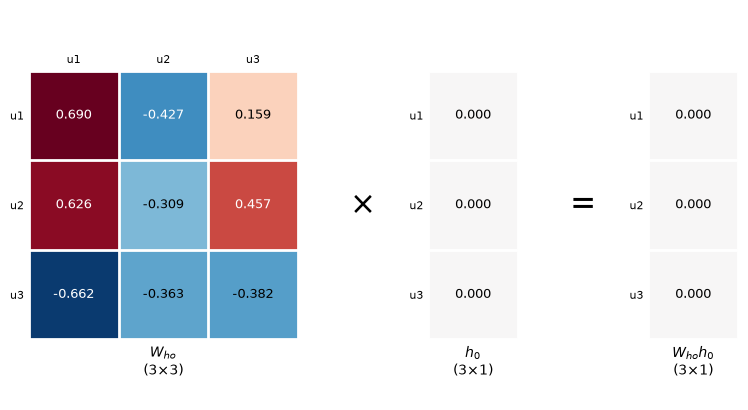

In [99]:
W_ho_h0 = W_ho @ h0          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_ho, h0, W_ho_h0, r"W_{ho}", r"h_0", r"W_{ho}h_0", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{ho}$: $\;(3\times1) + (3\times1) = (3\times1)$
(Since $W_{h\cdot}h_0 = \mathbf{0}$, the result is just the bias itself.)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

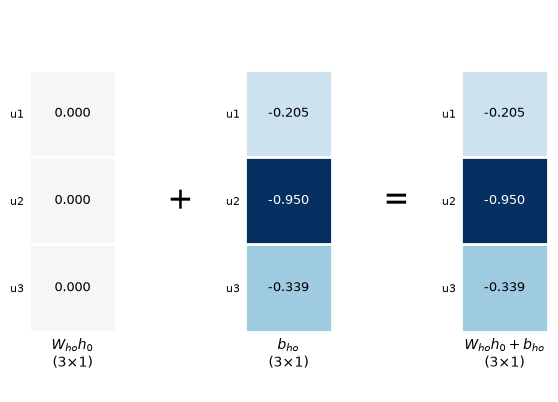

In [100]:
W_ho_h0_b = W_ho_h0 + b_ho       # (3x1) + (3x1) -> (3x1)
show_add([(W_ho_h0, r"W_{ho}h_0"), (b_ho, r"b_{ho}")], W_ho_h0_b, r"W_{ho}h_0 + b_{ho}")

**Step e — total pre-activation** $\;z^{(o)}_1 = (W_{io}x_1 + b_{io}) + (W_{ho}h_0 + b_{ho})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(o)}_1$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

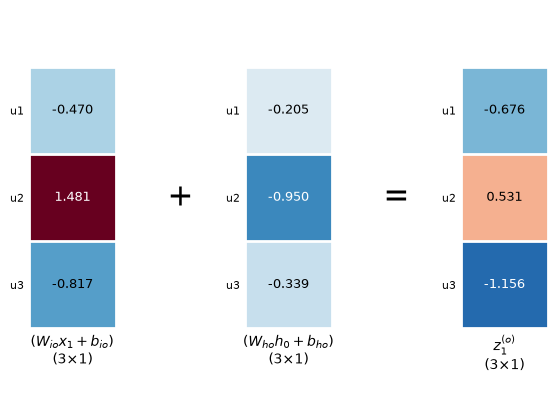

In [101]:
z_o1 = W_io_x1_b + W_ho_h0_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_io_x1_b, r"(W_{io}x_1 + b_{io})"), (W_ho_h0_b, r"(W_{ho}h_0 + b_{ho})")], z_o1, r"z^{(o)}_1")

**Step f — activation** $\;o_1 = \sigma(z^{(o)}_1)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

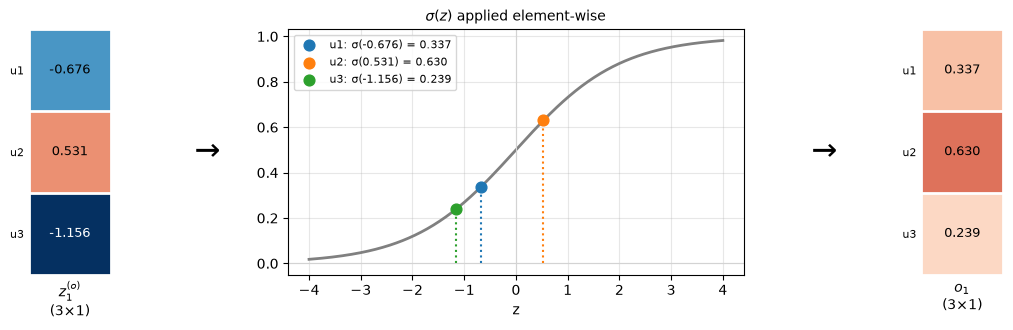

In [102]:
o1 = sigmoid(z_o1)          # element-wise -> (3x1)
show_activation(z_o1, o1, "sigmoid", r"z^{(o)}_1", r"o_1")

### 6.5 — Cell state update $c_1$

$$c_1 = \underbrace{f_1 \odot c_0}_{\text{keep part of the old memory}} \;+\; \underbrace{i_1 \odot g_1}_{\text{write part of the new candidate}}$$

Dimensions: $(3\times1)\odot(3\times1) + (3\times1)\odot(3\times1) = (3\times1)$. No matrices here — everything is **element-wise**,
so each hidden unit updates its own memory slot independently.

**Step a — forget term** $\;f_1 \odot c_0$
Since $c_0 = \mathbf{0}$, there is nothing to remember yet: the forget term is zero no matter what $f_1$ says.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

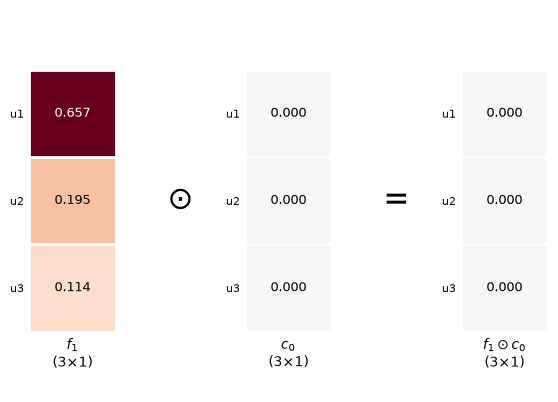

In [103]:
forget_term1 = f1 * c0      # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(f1, c0, forget_term1, "f_1", "c_0", r"f_1 \odot c_0")

**Step b — input term** $\;i_1 \odot g_1$

The candidate $g_1$ is scaled by the input gate: $i \approx 1$ writes the candidate fully, $i \approx 0$ blocks it.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

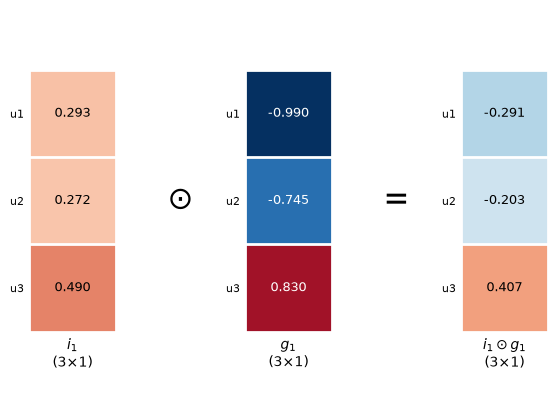

In [104]:
input_term1 = i1 * g1        # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(i1, g1, input_term1, "i_1", "g_1", r"i_1 \odot g_1")

**Step c — sum** $\;c_1 = f_1 \odot c_0 + i_1 \odot g_1$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

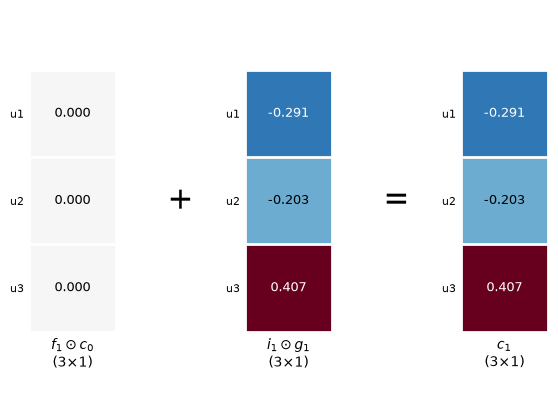

In [105]:
c1 = forget_term1 + input_term1   # (3x1) + (3x1) -> (3x1)
show_add([(forget_term1, r"f_1 \odot c_0"), (input_term1, r"i_1 \odot g_1")], c1, "c_1")

### 6.6 — Hidden state $h_1$

$$h_1 = o_1 \odot \tanh(c_1)$$

Dimensions: $(3\times1) \odot \tanh(3\times1) = (3\times1)$.

**Step a — squash the cell state** $\;\tanh(c_1)$

The cell state itself is unbounded (it can grow over many steps); $\tanh$ brings it back into $(-1, 1)$ before it is exposed.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

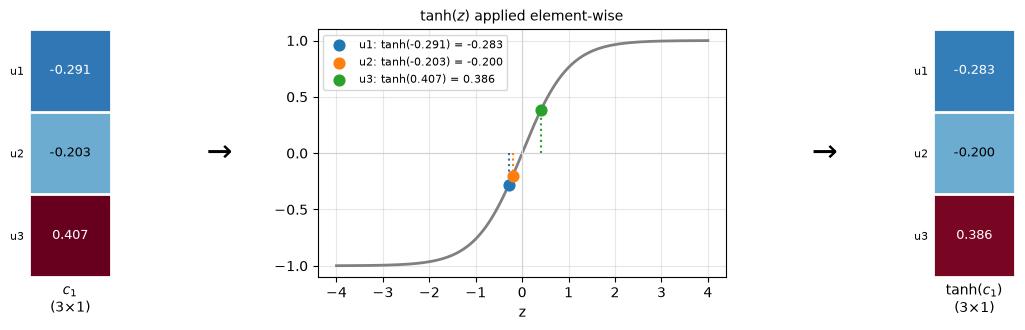

In [106]:
tanh_c1 = tanh(c1)             # element-wise -> (3x1)
show_activation(c1, tanh_c1, "tanh", "c_1", r"\tanh(c_1)")

**Step b — apply the output gate** $\;h_1 = o_1 \odot \tanh(c_1)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

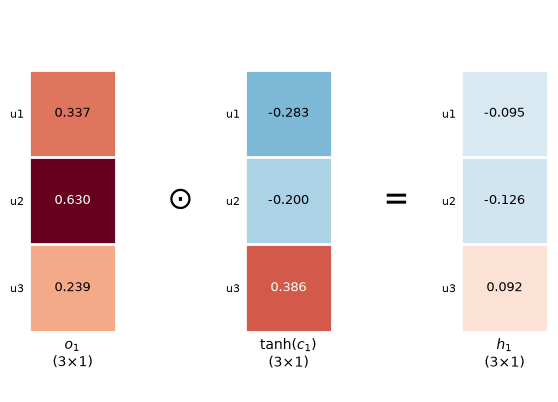

In [107]:
h1 = o1 * tanh_c1            # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(o1, tanh_c1, h1, "o_1", r"\tanh(c_1)", "h_1")

### 6.7 — Pass 1 summary

Everything computed for "Petryk" in one picture: inputs → four gates → new states.
$h_1$ and $c_1$ are what the next step receives.

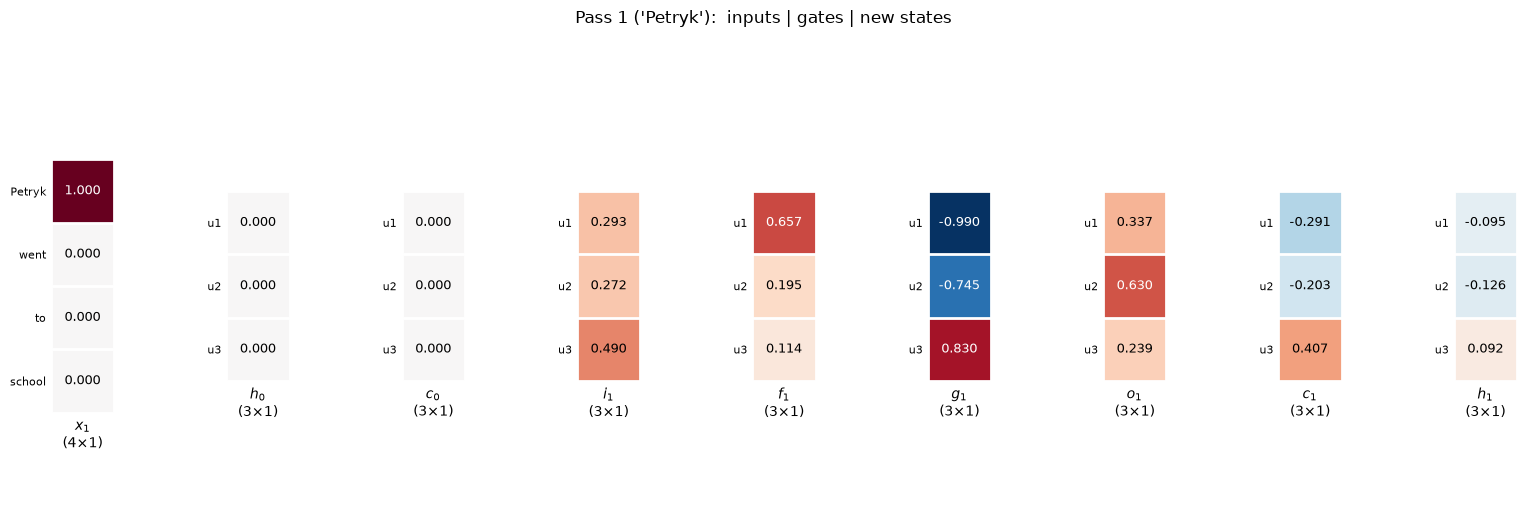

h_1 = [-0.0953 -0.1261  0.0923]
c_1 = [-0.2906 -0.2029  0.4066]


In [108]:
show_states([dict(M=x1, label="$x_1$", rows=tokens),
             dict(M=h0, label="$h_0$", rows=UNITS),
             dict(M=c0, label="$c_0$", rows=UNITS),
             dict(M=i1, label="$i_1$", rows=UNITS),
             dict(M=f1, label="$f_1$", rows=UNITS),
             dict(M=g1, label="$g_1$", rows=UNITS),
             dict(M=o1, label="$o_1$", rows=UNITS),
             dict(M=c1, label="$c_1$", rows=UNITS),
             dict(M=h1, label="$h_1$", rows=UNITS)],
            "Pass 1 ('Petryk'):  inputs | gates | new states")
print("h_1 =", h1.ravel())
print("c_1 =", c1.ravel())

---

## 7. Pass 2 — token $x_2$ = "went"

**Inputs of this step**

| Quantity | Where it comes from | Shape |
|----------|--------------------|-------|
| $x_2$ | one-hot vector of "went" (row 1 of `X`) | $4\times1$ |
| $h_1$ | hidden state produced by **Pass 1** | $3\times1$ |
| $c_1$ | cell state produced by **Pass 1** | $3\times1$ |

**Outputs:** $h_2$, $c_2$ (both $3\times1$).

Plan: compute the four gates $i_2, f_2, g_2, o_2$ (each in 6 small steps: matrix·vector, + bias,
matrix·vector, + bias, sum, activation), then the cell state $c_2$ and the hidden state $h_2$.

> This is where the **recurrence** becomes visible: unlike Pass 1, $h_1$ and $c_1$ are no longer zero,
> so the recurrent products $W_{h\cdot}\,h_1$ and the forget term $f_2 \odot c_1$ now contribute real numbers.
> This is how information about "Petryk" flows into the processing of "went".

x2 shape: (4, 1)  h1 shape: (3, 1)  c1 shape: (3, 1)


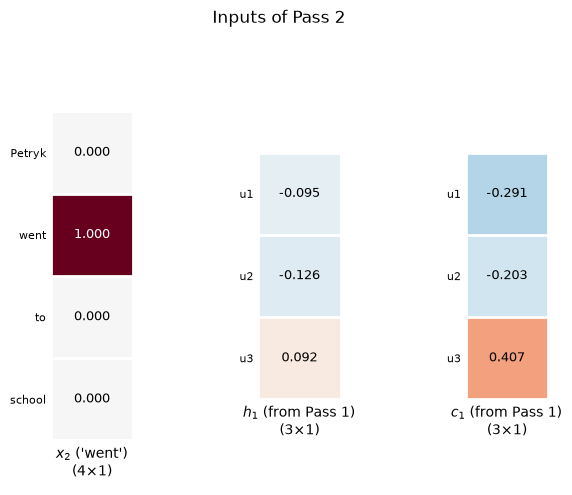

In [109]:
x2 = X[1].reshape(-1, 1)    # x_2 ∈ R^{4x1}: one-hot for "went"
# h1, c1 were computed in Pass 1 and are reused here — this IS the recurrence.

print("x2 shape:", x2.shape, " h1 shape:", h1.shape, " c1 shape:", c1.shape)
show_states([dict(M=x2, label="$x_2$ ('went')", rows=tokens),
             dict(M=h1, label="$h_1$ (from Pass 1)", rows=UNITS),
             dict(M=c1, label="$c_1$ (from Pass 1)", rows=UNITS)], "Inputs of Pass 2")

### 7.1 — Input gate $i_2$

$$i_2 = \sigma\big(\underbrace{W_{ii}\,x_2}_{\text{step a}} \underbrace{+\, b_{ii}}_{\text{step b}}
\;+\; \underbrace{W_{hi}\,h_1}_{\text{step c}} \underbrace{+\, b_{hi}}_{\text{step d}}\big)$$

The Input gate decides **how much of the new candidate** $g_t$ is written into the cell state. Values near 1 = "write", near 0 = "ignore".

**Step a — input projection** $\;W_{ii}\,x_2$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{ii}$ is dotted with $x_2$ (4 products, then summed).
Because $x_2$ is **one-hot** with the 1 at position 1 ("went"), every product is zero except one:
the result is simply **column 1 of $W_{ii}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

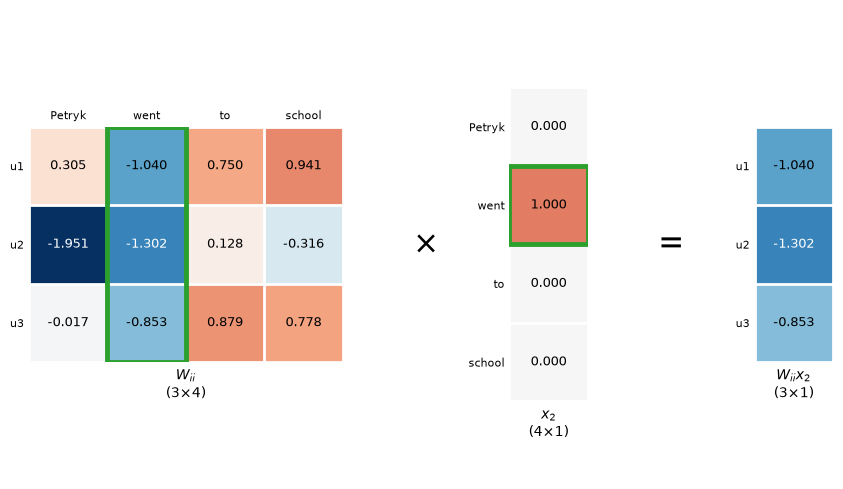

In [110]:
W_ii_x2 = W_ii @ x2          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_ii, x2, W_ii_x2, r"W_{ii}", r"x_2", r"W_{ii}x_2", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{ii}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

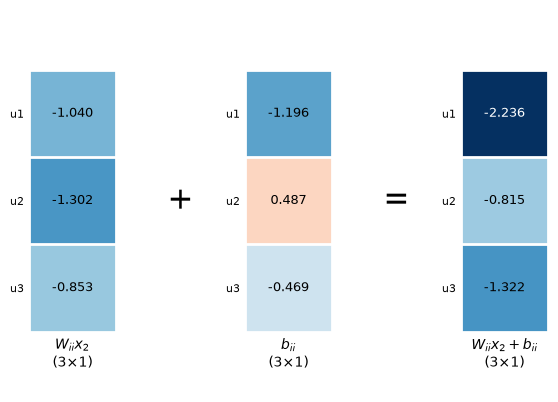

In [111]:
W_ii_x2_b = W_ii_x2 + b_ii       # (3x1) + (3x1) -> (3x1)
show_add([(W_ii_x2, r"W_{ii}x_2"), (b_ii, r"b_{ii}")], W_ii_x2_b, r"W_{ii}x_2 + b_{ii}")

**Step c — recurrent projection** $\;W_{hi}\,h_1$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hi}$ is dotted with the previous hidden state $h_1$ (3 products, then summed).
Now $h_1$ is **not** one-hot and not zero: all 3 entries are real numbers, so all 3 products in each row contribute. This is the memory of \"Petryk\" entering the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

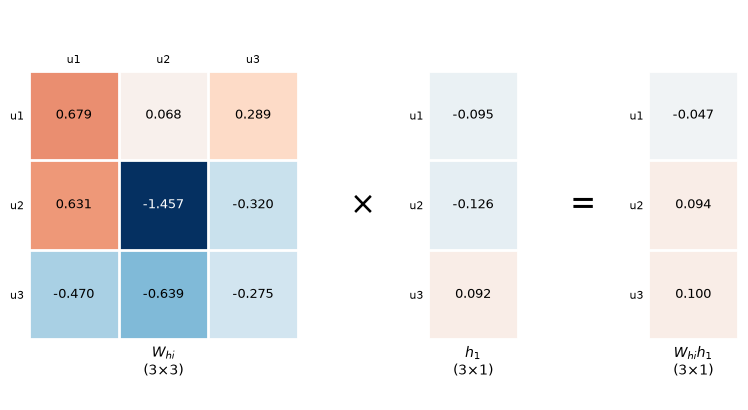

In [112]:
W_hi_h1 = W_hi @ h1          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hi, h1, W_hi_h1, r"W_{hi}", r"h_1", r"W_{hi}h_1", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hi}$: $\;(3\times1) + (3\times1) = (3\times1)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

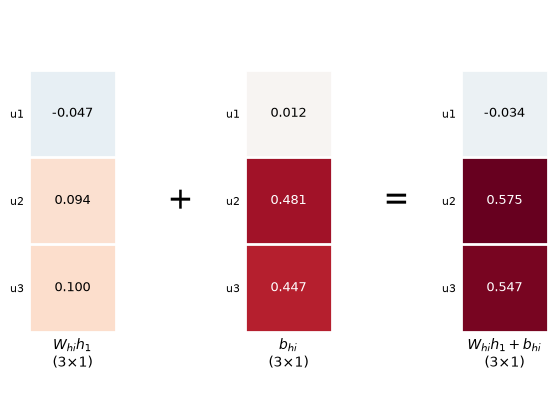

In [113]:
W_hi_h1_b = W_hi_h1 + b_hi       # (3x1) + (3x1) -> (3x1)
show_add([(W_hi_h1, r"W_{hi}h_1"), (b_hi, r"b_{hi}")], W_hi_h1_b, r"W_{hi}h_1 + b_{hi}")

**Step e — total pre-activation** $\;z^{(i)}_2 = (W_{ii}x_2 + b_{ii}) + (W_{hi}h_1 + b_{hi})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(i)}_2$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

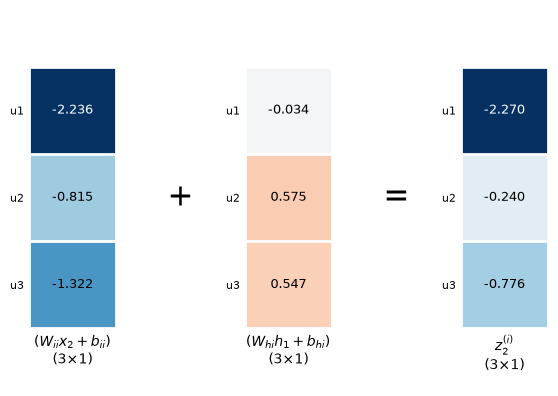

In [114]:
z_i2 = W_ii_x2_b + W_hi_h1_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_ii_x2_b, r"(W_{ii}x_2 + b_{ii})"), (W_hi_h1_b, r"(W_{hi}h_1 + b_{hi})")], z_i2, r"z^{(i)}_2")

**Step f — activation** $\;i_2 = \sigma(z^{(i)}_2)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

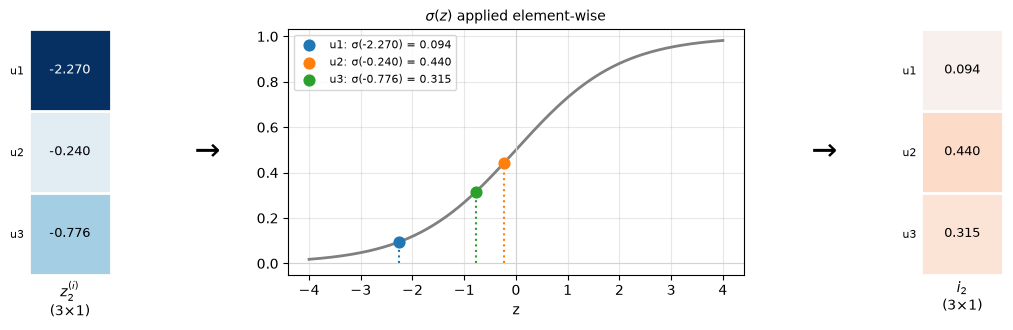

In [115]:
i2 = sigmoid(z_i2)          # element-wise -> (3x1)
show_activation(z_i2, i2, "sigmoid", r"z^{(i)}_2", r"i_2")

### 7.2 — Forget gate $f_2$

$$f_2 = \sigma\big(\underbrace{W_{if}\,x_2}_{\text{step a}} \underbrace{+\, b_{if}}_{\text{step b}}
\;+\; \underbrace{W_{hf}\,h_1}_{\text{step c}} \underbrace{+\, b_{hf}}_{\text{step d}}\big)$$

The Forget gate decides **how much of the old cell state** $c_{t-1}$ is kept. Values near 1 = "remember", near 0 = "forget".

**Step a — input projection** $\;W_{if}\,x_2$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{if}$ is dotted with $x_2$ (4 products, then summed).
Because $x_2$ is **one-hot** with the 1 at position 1 ("went"), every product is zero except one:
the result is simply **column 1 of $W_{if}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

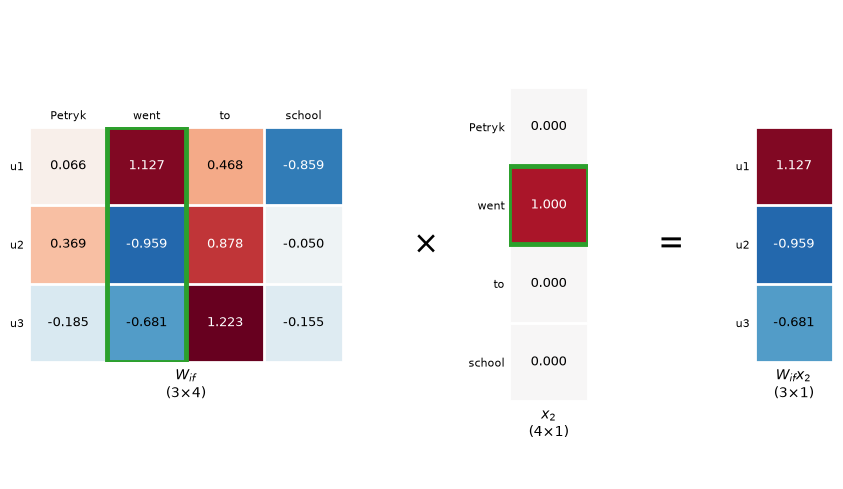

In [116]:
W_if_x2 = W_if @ x2          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_if, x2, W_if_x2, r"W_{if}", r"x_2", r"W_{if}x_2", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{if}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

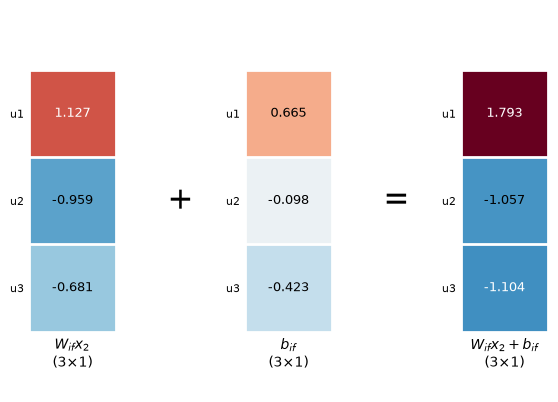

In [117]:
W_if_x2_b = W_if_x2 + b_if       # (3x1) + (3x1) -> (3x1)
show_add([(W_if_x2, r"W_{if}x_2"), (b_if, r"b_{if}")], W_if_x2_b, r"W_{if}x_2 + b_{if}")

**Step c — recurrent projection** $\;W_{hf}\,h_1$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hf}$ is dotted with the previous hidden state $h_1$ (3 products, then summed).
Now $h_1$ is **not** one-hot and not zero: all 3 entries are real numbers, so all 3 products in each row contribute. This is the memory of \"Petryk\" entering the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

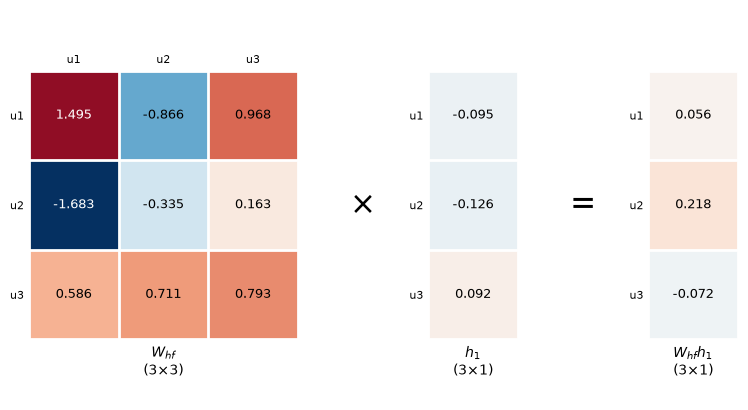

In [118]:
W_hf_h1 = W_hf @ h1          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hf, h1, W_hf_h1, r"W_{hf}", r"h_1", r"W_{hf}h_1", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hf}$: $\;(3\times1) + (3\times1) = (3\times1)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

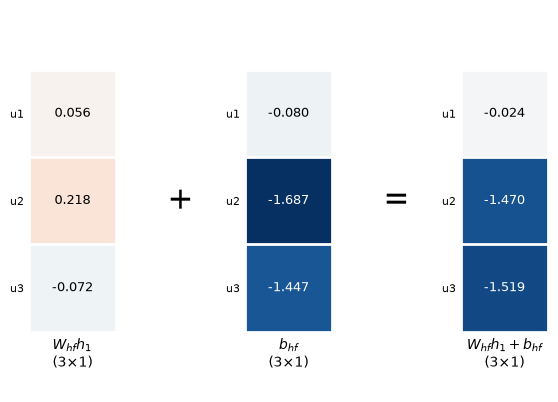

In [119]:
W_hf_h1_b = W_hf_h1 + b_hf       # (3x1) + (3x1) -> (3x1)
show_add([(W_hf_h1, r"W_{hf}h_1"), (b_hf, r"b_{hf}")], W_hf_h1_b, r"W_{hf}h_1 + b_{hf}")

**Step e — total pre-activation** $\;z^{(f)}_2 = (W_{if}x_2 + b_{if}) + (W_{hf}h_1 + b_{hf})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(f)}_2$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

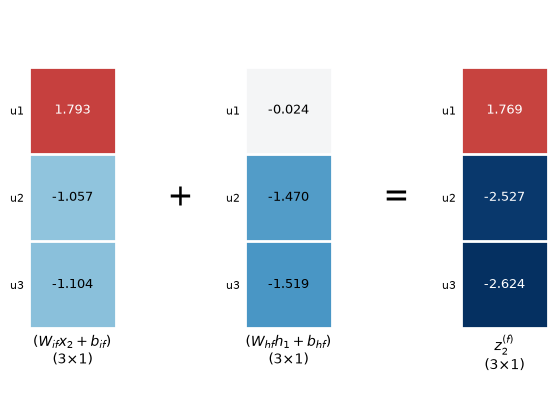

In [120]:
z_f2 = W_if_x2_b + W_hf_h1_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_if_x2_b, r"(W_{if}x_2 + b_{if})"), (W_hf_h1_b, r"(W_{hf}h_1 + b_{hf})")], z_f2, r"z^{(f)}_2")

**Step f — activation** $\;f_2 = \sigma(z^{(f)}_2)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

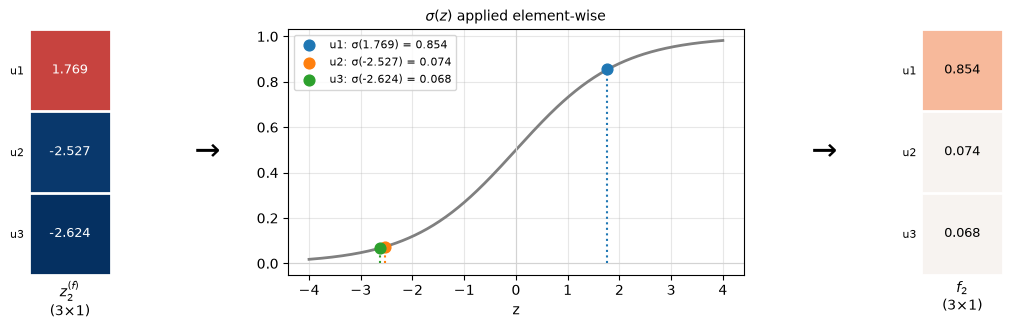

In [121]:
f2 = sigmoid(z_f2)          # element-wise -> (3x1)
show_activation(z_f2, f2, "sigmoid", r"z^{(f)}_2", r"f_2")

### 7.3 — Cell candidate $g_2$

$$g_2 = \tanh\big(\underbrace{W_{ig}\,x_2}_{\text{step a}} \underbrace{+\, b_{ig}}_{\text{step b}}
\;+\; \underbrace{W_{hg}\,h_1}_{\text{step c}} \underbrace{+\, b_{hg}}_{\text{step d}}\big)$$

The Cell candidate proposes **new content** for the cell state, in the range $(-1, 1)$. It is not a gate — it is the information itself, hence $\tanh$ instead of $\sigma$.

**Step a — input projection** $\;W_{ig}\,x_2$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{ig}$ is dotted with $x_2$ (4 products, then summed).
Because $x_2$ is **one-hot** with the 1 at position 1 ("went"), every product is zero except one:
the result is simply **column 1 of $W_{ig}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

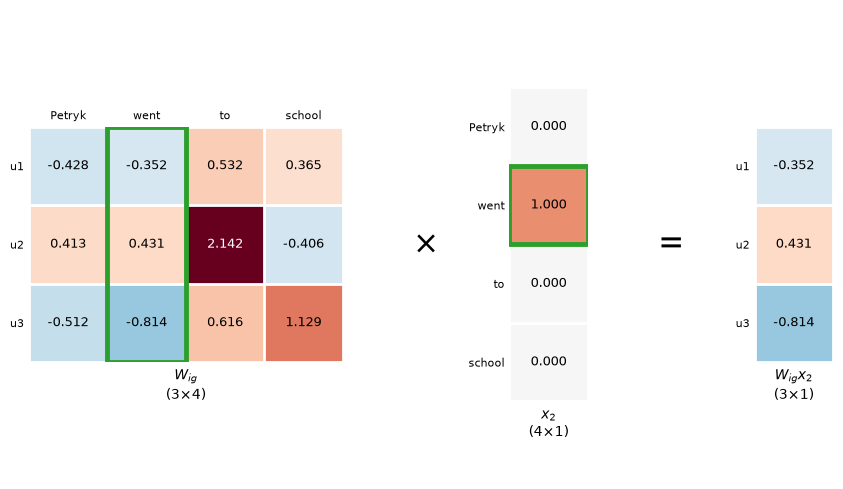

In [122]:
W_ig_x2 = W_ig @ x2          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_ig, x2, W_ig_x2, r"W_{ig}", r"x_2", r"W_{ig}x_2", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{ig}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

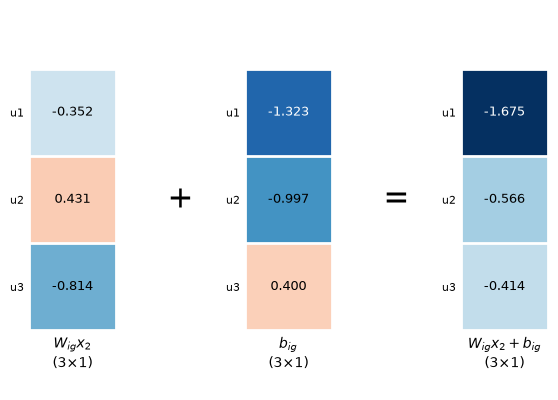

In [123]:
W_ig_x2_b = W_ig_x2 + b_ig       # (3x1) + (3x1) -> (3x1)
show_add([(W_ig_x2, r"W_{ig}x_2"), (b_ig, r"b_{ig}")], W_ig_x2_b, r"W_{ig}x_2 + b_{ig}")

**Step c — recurrent projection** $\;W_{hg}\,h_1$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{hg}$ is dotted with the previous hidden state $h_1$ (3 products, then summed).
Now $h_1$ is **not** one-hot and not zero: all 3 entries are real numbers, so all 3 products in each row contribute. This is the memory of \"Petryk\" entering the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

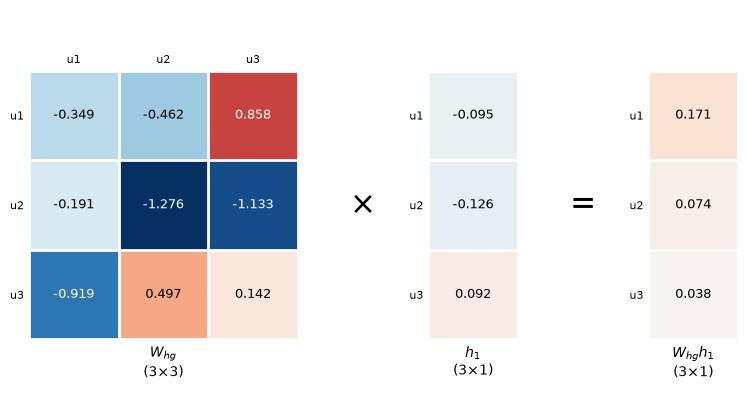

In [124]:
W_hg_h1 = W_hg @ h1          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_hg, h1, W_hg_h1, r"W_{hg}", r"h_1", r"W_{hg}h_1", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{hg}$: $\;(3\times1) + (3\times1) = (3\times1)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

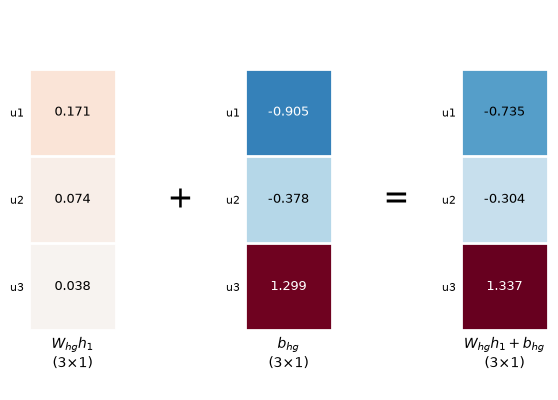

In [125]:
W_hg_h1_b = W_hg_h1 + b_hg       # (3x1) + (3x1) -> (3x1)
show_add([(W_hg_h1, r"W_{hg}h_1"), (b_hg, r"b_{hg}")], W_hg_h1_b, r"W_{hg}h_1 + b_{hg}")

**Step e — total pre-activation** $\;z^{(g)}_2 = (W_{ig}x_2 + b_{ig}) + (W_{hg}h_1 + b_{hg})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(g)}_2$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

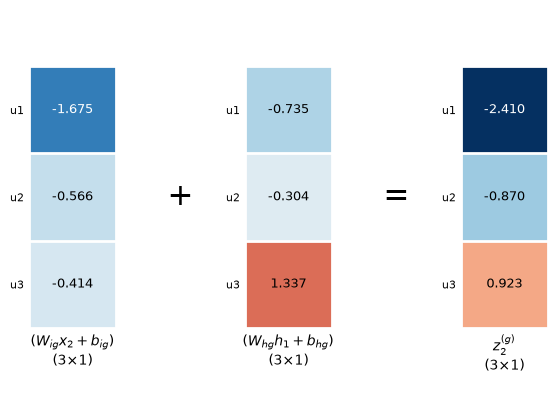

In [126]:
z_g2 = W_ig_x2_b + W_hg_h1_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_ig_x2_b, r"(W_{ig}x_2 + b_{ig})"), (W_hg_h1_b, r"(W_{hg}h_1 + b_{hg})")], z_g2, r"z^{(g)}_2")

**Step f — activation** $\;g_2 = \tanh(z^{(g)}_2)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\tanh$ maps every entry into $(-1, 1)$, so the candidate can push the cell state **up or down**. $\tanh(0) = 0$.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

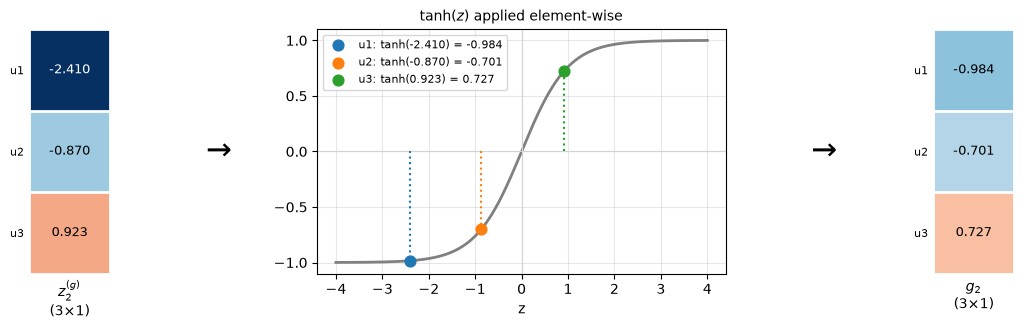

In [127]:
g2 = tanh(z_g2)          # element-wise -> (3x1)
show_activation(z_g2, g2, "tanh", r"z^{(g)}_2", r"g_2")

### 7.4 — Output gate $o_2$

$$o_2 = \sigma\big(\underbrace{W_{io}\,x_2}_{\text{step a}} \underbrace{+\, b_{io}}_{\text{step b}}
\;+\; \underbrace{W_{ho}\,h_1}_{\text{step c}} \underbrace{+\, b_{ho}}_{\text{step d}}\big)$$

The Output gate decides **how much of the (squashed) cell state** $\tanh(c_t)$ is exposed as the hidden state $h_t$.

**Step a — input projection** $\;W_{io}\,x_2$: $\;(3\times4)\cdot(4\times1) = (3\times1)$

Each of the 3 rows of $W_{io}$ is dotted with $x_2$ (4 products, then summed).
Because $x_2$ is **one-hot** with the 1 at position 1 ("went"), every product is zero except one:
the result is simply **column 1 of $W_{io}$** (highlighted in green). This is why one-hot inputs times a weight
matrix are just a "table lookup" — exactly what an embedding layer does.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

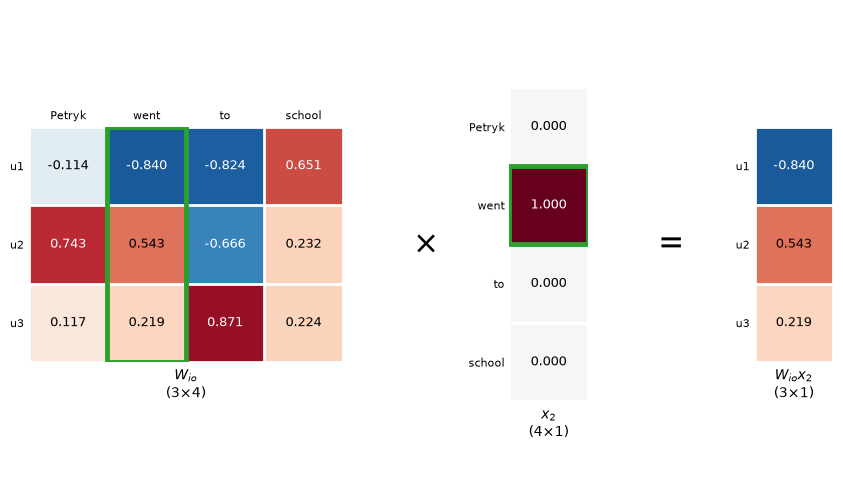

In [128]:
W_io_x2 = W_io @ x2          # (3x4) @ (4x1) -> (3x1)
show_matvec(W_io, x2, W_io_x2, r"W_{io}", r"x_2", r"W_{io}x_2", W_cols=tokens, v_rows=tokens)

**Step b — add the input bias** $\;b_{io}$: $\;(3\times1) + (3\times1) = (3\times1)$

Element-wise addition: unit 1 + unit 1, unit 2 + unit 2, unit 3 + unit 3.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

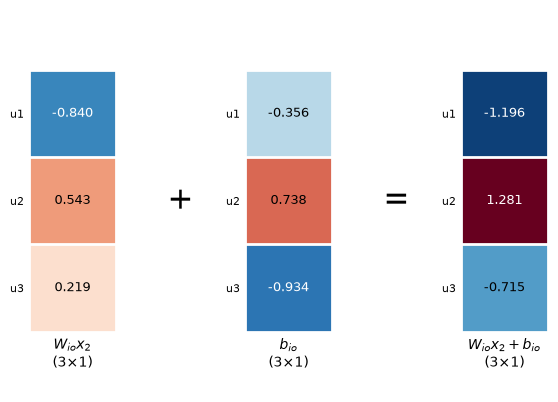

In [129]:
W_io_x2_b = W_io_x2 + b_io       # (3x1) + (3x1) -> (3x1)
show_add([(W_io_x2, r"W_{io}x_2"), (b_io, r"b_{io}")], W_io_x2_b, r"W_{io}x_2 + b_{io}")

**Step c — recurrent projection** $\;W_{ho}\,h_1$: $\;(3\times3)\cdot(3\times1) = (3\times1)$

Each row of $W_{ho}$ is dotted with the previous hidden state $h_1$ (3 products, then summed).
Now $h_1$ is **not** one-hot and not zero: all 3 entries are real numbers, so all 3 products in each row contribute. This is the memory of \"Petryk\" entering the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

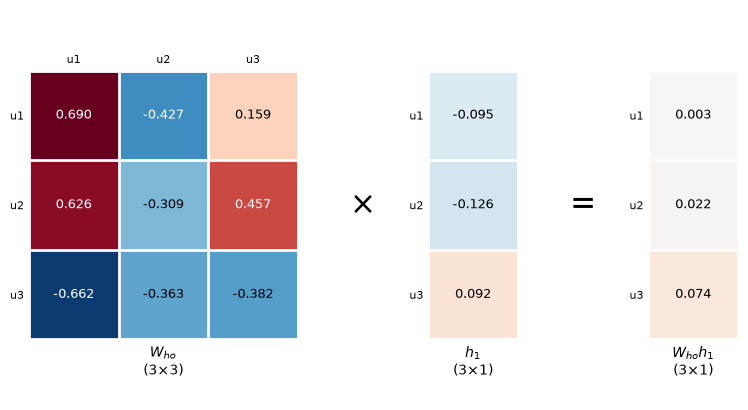

In [130]:
W_ho_h1 = W_ho @ h1          # (3x3) @ (3x1) -> (3x1)
show_matvec(W_ho, h1, W_ho_h1, r"W_{ho}", r"h_1", r"W_{ho}h_1", W_cols=UNITS, v_rows=UNITS)

**Step d — add the recurrent bias** $\;b_{ho}$: $\;(3\times1) + (3\times1) = (3\times1)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

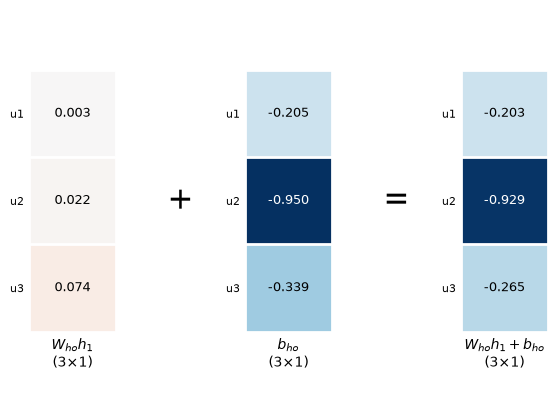

In [131]:
W_ho_h1_b = W_ho_h1 + b_ho       # (3x1) + (3x1) -> (3x1)
show_add([(W_ho_h1, r"W_{ho}h_1"), (b_ho, r"b_{ho}")], W_ho_h1_b, r"W_{ho}h_1 + b_{ho}")

**Step e — total pre-activation** $\;z^{(o)}_2 = (W_{io}x_2 + b_{io}) + (W_{ho}h_1 + b_{ho})$: $\;(3\times1) + (3\times1) = (3\times1)$

The input part and the recurrent part are summed. $z^{(o)}_2$ is often called the *logit* or *pre-activation* of the gate.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

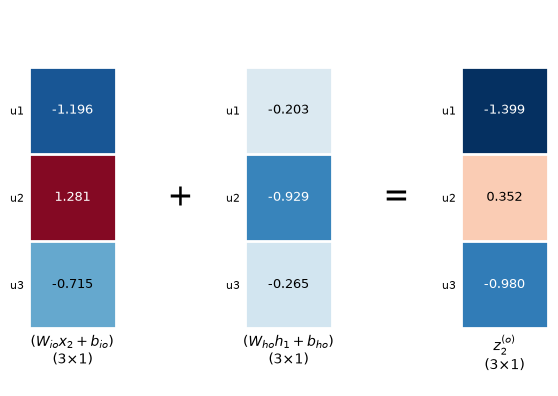

In [132]:
z_o2 = W_io_x2_b + W_ho_h1_b       # (3x1) + (3x1) -> (3x1)
show_add([(W_io_x2_b, r"(W_{io}x_2 + b_{io})"), (W_ho_h1_b, r"(W_{ho}h_1 + b_{ho})")], z_o2, r"z^{(o)}_2")

**Step f — activation** $\;o_2 = \sigma(z^{(o)}_2)$: $\;(3\times1) \rightarrow (3\times1)$, element by element.

$\sigma$ maps every entry into $(0, 1)$: large positive $z$ → close to 1 (gate open), large negative $z$ → close to 0 (gate closed), $z = 0$ → exactly 0.5.
On the plot, each coloured dot is one hidden unit: its $z$ on the x-axis, its activation on the y-axis.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

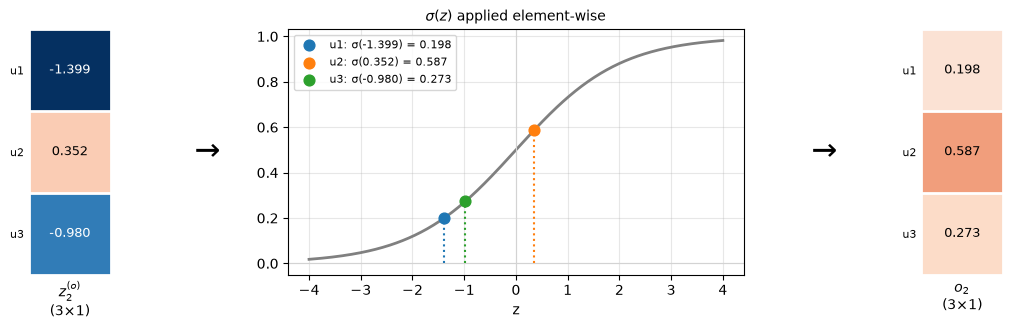

In [133]:
o2 = sigmoid(z_o2)          # element-wise -> (3x1)
show_activation(z_o2, o2, "sigmoid", r"z^{(o)}_2", r"o_2")

### 7.5 — Cell state update $c_2$

$$c_2 = \underbrace{f_2 \odot c_1}_{\text{keep part of the old memory}} \;+\; \underbrace{i_2 \odot g_2}_{\text{write part of the new candidate}}$$

Dimensions: $(3\times1)\odot(3\times1) + (3\times1)\odot(3\times1) = (3\times1)$. No matrices here — everything is **element-wise**,
so each hidden unit updates its own memory slot independently.

**Step a — forget term** $\;f_2 \odot c_1$
Each unit multiplies its old memory $c_1$ by its forget-gate value: $f \approx 1$ keeps it, $f \approx 0$ erases it.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

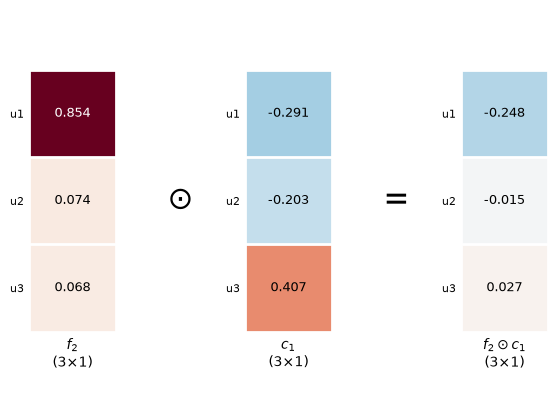

In [134]:
forget_term2 = f2 * c1      # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(f2, c1, forget_term2, "f_2", "c_1", r"f_2 \odot c_1")

**Step b — input term** $\;i_2 \odot g_2$

The candidate $g_2$ is scaled by the input gate: $i \approx 1$ writes the candidate fully, $i \approx 0$ blocks it.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

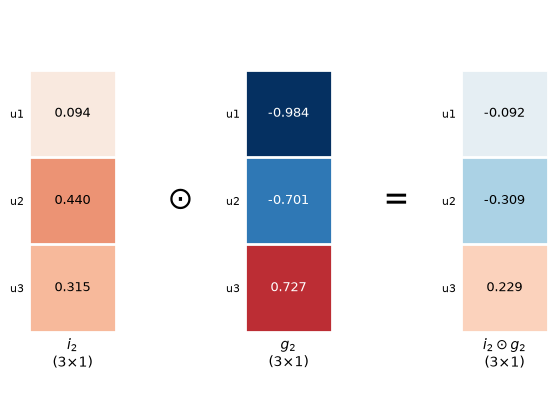

In [135]:
input_term2 = i2 * g2        # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(i2, g2, input_term2, "i_2", "g_2", r"i_2 \odot g_2")

**Step c — sum** $\;c_2 = f_2 \odot c_1 + i_2 \odot g_2$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

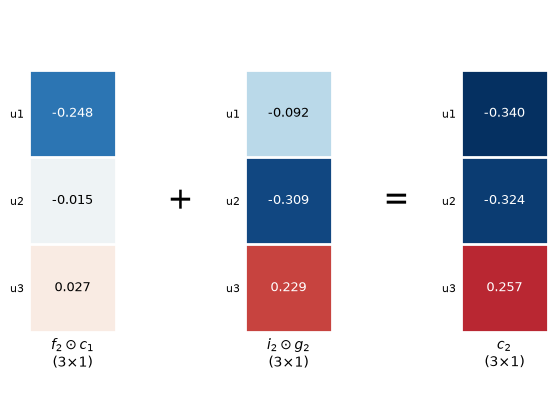

In [136]:
c2 = forget_term2 + input_term2   # (3x1) + (3x1) -> (3x1)
show_add([(forget_term2, r"f_2 \odot c_1"), (input_term2, r"i_2 \odot g_2")], c2, "c_2")

### 7.6 — Hidden state $h_2$

$$h_2 = o_2 \odot \tanh(c_2)$$

Dimensions: $(3\times1) \odot \tanh(3\times1) = (3\times1)$.

**Step a — squash the cell state** $\;\tanh(c_2)$

The cell state itself is unbounded (it can grow over many steps); $\tanh$ brings it back into $(-1, 1)$ before it is exposed.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

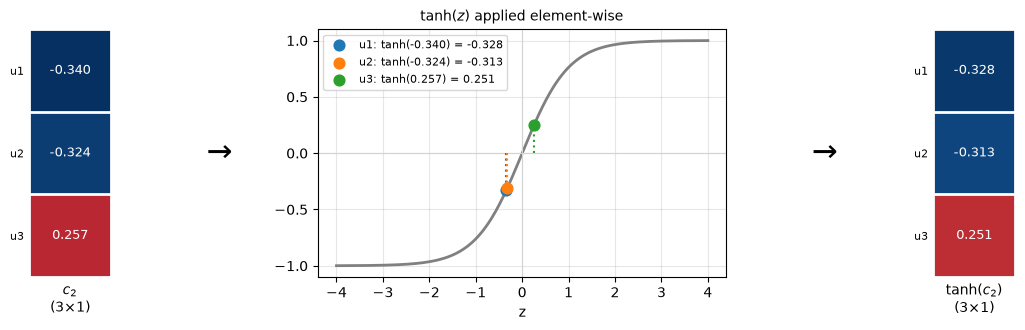

In [137]:
tanh_c2 = tanh(c2)             # element-wise -> (3x1)
show_activation(c2, tanh_c2, "tanh", "c_2", r"\tanh(c_2)")

**Step b — apply the output gate** $\;h_2 = o_2 \odot \tanh(c_2)$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

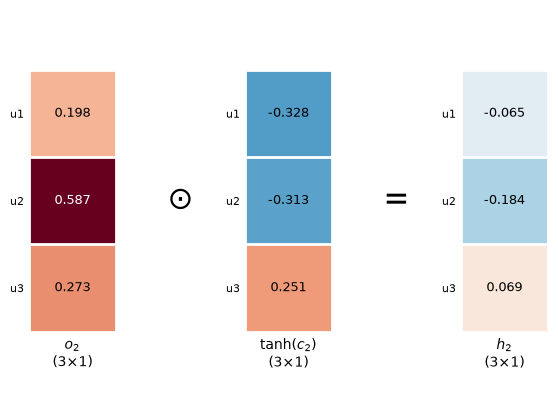

In [138]:
h2 = o2 * tanh_c2            # (3x1) ⊙ (3x1) -> (3x1)
show_hadamard(o2, tanh_c2, h2, "o_2", r"\tanh(c_2)", "h_2")

### 7.7 — Pass 2 summary

Everything computed for "went" in one picture: inputs → four gates → new states.
$h_2$ and $c_2$ are what the next step receives.

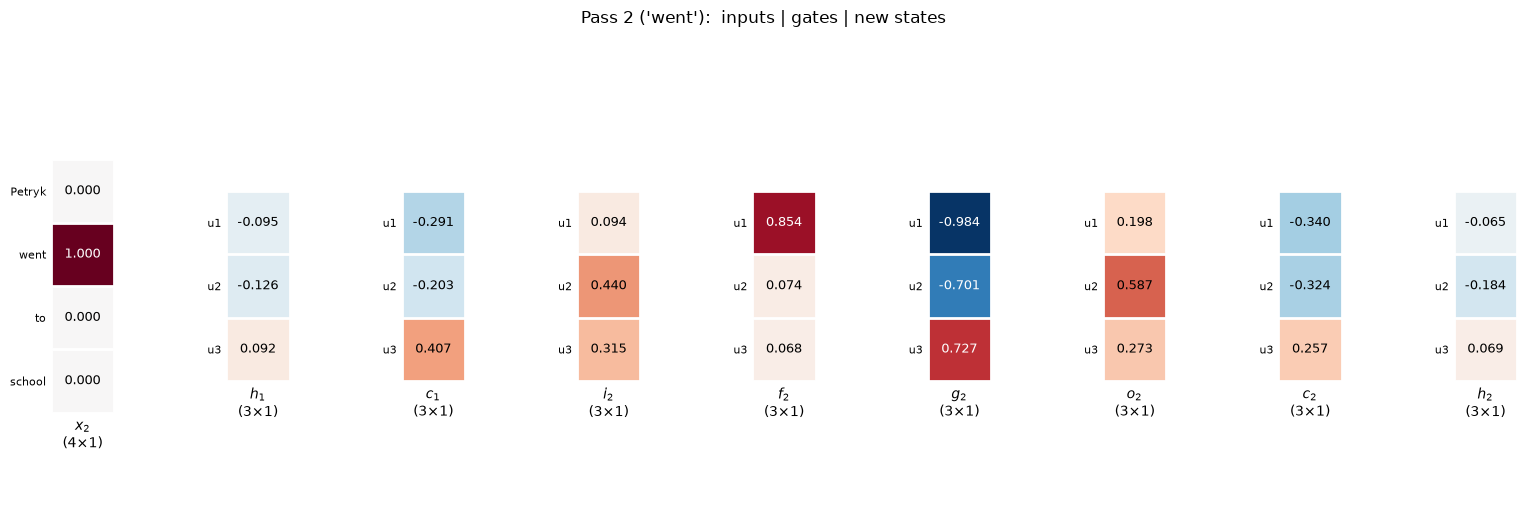

h_2 = [-0.0649 -0.1837  0.0686]
c_2 = [-0.3404 -0.3238  0.2568]


In [139]:
show_states([dict(M=x2, label="$x_2$", rows=tokens),
             dict(M=h1, label="$h_1$", rows=UNITS),
             dict(M=c1, label="$c_1$", rows=UNITS),
             dict(M=i2, label="$i_2$", rows=UNITS),
             dict(M=f2, label="$f_2$", rows=UNITS),
             dict(M=g2, label="$g_2$", rows=UNITS),
             dict(M=o2, label="$o_2$", rows=UNITS),
             dict(M=c2, label="$c_2$", rows=UNITS),
             dict(M=h2, label="$h_2$", rows=UNITS)],
            "Pass 2 ('went'):  inputs | gates | new states")
print("h_2 =", h2.ravel())
print("c_2 =", c2.ravel())

### 7.8 — What changed between Pass 1 and Pass 2?

The weights are **the same** in both passes. The differences come from two places:

1. **A different input**: $x_2$ selects a different column of every $W_{i\cdot}$ (column 1 instead of column 0).
2. **Memory**: $h_1 \neq \mathbf{0}$ makes $W_{h\cdot}h_1$ non-zero, and $c_1 \neq \mathbf{0}$ makes $f_2 \odot c_1$ non-zero.

The plot below shows the recurrent contribution $W_{h\cdot}h_{t-1}$ for each gate in both passes —
all zeros in Pass 1, real numbers in Pass 2.

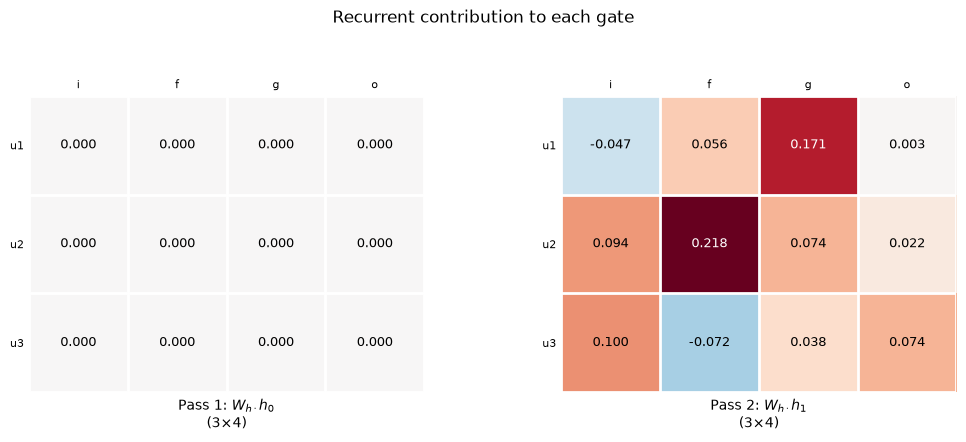

In [140]:
show_states([dict(M=np.hstack([W_hi_h0, W_hf_h0, W_hg_h0, W_ho_h0]), label=r"Pass 1: $W_{h\cdot}h_0$",
                  rows=UNITS, cols=["i", "f", "g", "o"]),
             dict(M=np.hstack([W_hi_h1, W_hf_h1, W_hg_h1, W_ho_h1]), label=r"Pass 2: $W_{h\cdot}h_1$",
                  rows=UNITS, cols=["i", "f", "g", "o"])],
            "Recurrent contribution to each gate")

---

## 8. The Whole Sentence — Compact Loop

Now that every operation is clear, the same six equations fit in a small function. We run it over all 4 tokens
and check that the first two steps reproduce Pass 1 and Pass 2 exactly.

t=1 'Petryk':  h = [-0.0953 -0.1261  0.0923]   c = [-0.2906 -0.2029  0.4066]
t=2 '  went':  h = [-0.0649 -0.1837  0.0686]   c = [-0.3404 -0.3238  0.2568]
t=3 '    to':  h = [-0.1129  0.1331  0.2786]   c = [-0.6107  0.4705  0.7952]
t=4 'school':  h = [-0.2931 -0.229   0.1578]   c = [-0.6727 -0.4849  0.7684]

Pass 1 matches loop: True
Pass 2 matches loop: True


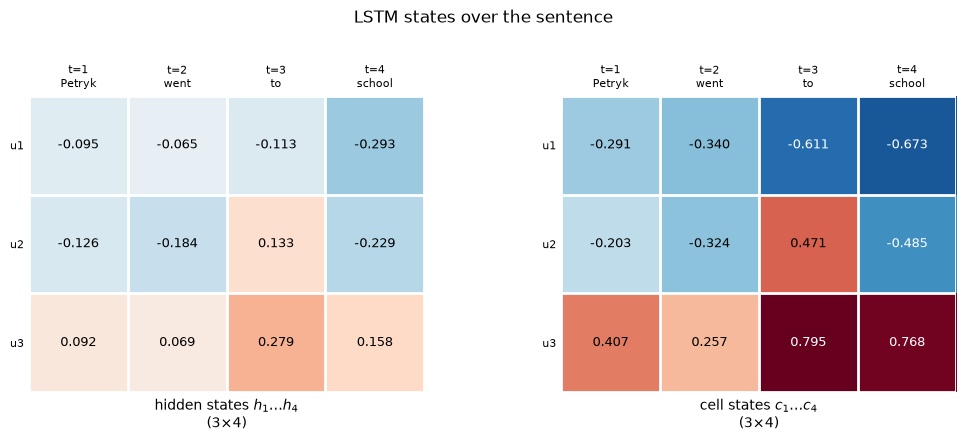

In [141]:
def lstm_step(x, h_prev, c_prev):
    i = sigmoid(W_ii @ x + b_ii + W_hi @ h_prev + b_hi)
    f = sigmoid(W_if @ x + b_if + W_hf @ h_prev + b_hf)
    g = tanh(   W_ig @ x + b_ig + W_hg @ h_prev + b_hg)
    o = sigmoid(W_io @ x + b_io + W_ho @ h_prev + b_ho)
    c = f * c_prev + i * g
    h = o * tanh(c)
    return h, c

h = np.zeros((hidden_size, 1))
c = np.zeros((hidden_size, 1))
all_h, all_c = [], []
for t in range(seq_len):
    h, c = lstm_step(X[t].reshape(-1, 1), h, c)
    all_h.append(h)
    all_c.append(c)
    print(f"t={t + 1} '{tokens[t]:>6}':  h = {h.ravel()}   c = {c.ravel()}")

print("\nPass 1 matches loop:", np.allclose(h1, all_h[0]) and np.allclose(c1, all_c[0]))
print("Pass 2 matches loop:", np.allclose(h2, all_h[1]) and np.allclose(c2, all_c[1]))

H = np.hstack(all_h)   # (3 x 4): column t = h_t
C = np.hstack(all_c)
cols = [f"t={k + 1}\n{tok}" for k, tok in enumerate(tokens)]
show_states([dict(M=H, label="hidden states $h_1 \\ldots h_4$", rows=UNITS, cols=cols),
             dict(M=C, label="cell states $c_1 \\ldots c_4$", rows=UNITS, cols=cols)],
            "LSTM states over the sentence")

## 9. Verification with PyTorch `nn.LSTM`

PyTorch keeps the four gates **stacked** in one matrix, in the order $(i, f, g, o)$:

- `weight_ih_l0` $= [W_{ii}; W_{if}; W_{ig}; W_{io}] \in \mathbb{R}^{12\times4}$ — that's $4 \cdot \text{hidden\_size} = 12$ rows
- `weight_hh_l0` $= [W_{hi}; W_{hf}; W_{hg}; W_{ho}] \in \mathbb{R}^{12\times3}$
- `bias_ih_l0`, `bias_hh_l0` $\in \mathbb{R}^{12}$

So PyTorch does **one** $(12\times4)\cdot(4\times1)$ product instead of our four $(3\times4)\cdot(4\times1)$ products —
same numbers, just faster. We copy our weights in and compare.

In [142]:
import torch

lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=layers, batch_first=True)
with torch.no_grad():
    lstm.weight_ih_l0.copy_(torch.tensor(np.vstack([W_ii, W_if, W_ig, W_io])))
    lstm.weight_hh_l0.copy_(torch.tensor(np.vstack([W_hi, W_hf, W_hg, W_ho])))
    lstm.bias_ih_l0.copy_(torch.tensor(np.vstack([b_ii, b_if, b_ig, b_io]).ravel()))
    lstm.bias_hh_l0.copy_(torch.tensor(np.vstack([b_hi, b_hf, b_hg, b_ho]).ravel()))

print("weight_ih_l0:", tuple(lstm.weight_ih_l0.shape), " weight_hh_l0:", tuple(lstm.weight_hh_l0.shape))

x_torch = torch.tensor(X, dtype=torch.float32).unsqueeze(0)   # (batch=1, seq_len=4, input_size=4)
with torch.no_grad():
    out, (h_n, c_n) = lstm(x_torch)

print("output shape:", tuple(out.shape), " (batch, seq_len, hidden_size)")
print("\nPyTorch h_t (rows = t):\n", out[0].numpy())
print("NumPy   h_t (rows = t):\n", H.T)
print("\nAll hidden states match:", np.allclose(out[0].numpy(), H.T, atol=1e-5))
print("Final cell state matches:", np.allclose(c_n[0, 0].numpy(), C[:, -1], atol=1e-5))

weight_ih_l0: (12, 4)  weight_hh_l0: (12, 3)
output shape: (1, 4, 3)  (batch, seq_len, hidden_size)

PyTorch h_t (rows = t):
 [[-0.0953 -0.1261  0.0923]
 [-0.0649 -0.1837  0.0686]
 [-0.1129  0.1331  0.2786]
 [-0.2931 -0.229   0.1578]]
NumPy   h_t (rows = t):
 [[-0.0953 -0.1261  0.0923]
 [-0.0649 -0.1837  0.0686]
 [-0.1129  0.1331  0.2786]
 [-0.2931 -0.229   0.1578]]

All hidden states match: True
Final cell state matches: True


---

## 10. Summary

| Operation | Shapes | Count per time step |
|-----------|--------|---------------------|
| $W_{i\cdot}\,x_t$ | $(3\times4)\cdot(4\times1) \to 3\times1$ | 4 (one per gate) |
| $W_{h\cdot}\,h_{t-1}$ | $(3\times3)\cdot(3\times1) \to 3\times1$ | 4 |
| bias additions | $(3\times1)+(3\times1)$ | 8 |
| $\sigma$ / $\tanh$ | element-wise on $3\times1$ | 3 σ + 2 tanh |
| $\odot$ | $(3\times1)\odot(3\times1)$ | 3 ($f\odot c$, $i\odot g$, $o\odot\tanh c$) |

**Key takeaways:**
1. A one-hot $x_t$ times $W_{i\cdot}$ simply **selects a column** — an embedding lookup.
2. All 4 gates depend only on $x_t$ and $h_{t-1}$, so they can be computed **in parallel** (PyTorch stacks them into one $12\times\cdot$ matrix).
3. In the first step $h_0 = c_0 = \mathbf{0}$, so the recurrent terms vanish; from the second step on, **memory flows in** through $W_{h\cdot}h_{t-1}$ and $f_t \odot c_{t-1}$.
4. The cell state update is **element-wise**: each unit has its own memory slot, guarded by its own forget and input gate values.
5. $\sigma$ produces valves in $(0,1)$; $\tanh$ produces content in $(-1,1)$.